Perbandingan Algoritma Naive Bayes, K-Nearest Neighbor, dan Decision Tree untuk Prediksi Penyakit Jantung dengan Interpretabilitas Model Berbasis SHAP


## Identitas Kelompok

| Nama | NIM |
|------|-----|
| Farel Hagasa Tarigan          | 103032400032 |
| Naza Saputra                  | 103032400143 |
| M.Ataulloh Al Ghafiqi Alvin   | 103032430004 |
| Andrian Karim                 | 103032400046 |

---









# 1. Pendahuluan

## 1.1 Latar Belakang

Penyakit jantung merupakan salah satu penyebab kematian tertinggi secara global yang hingga kini masih menjadi tantangan serius dalam dunia kesehatan. Menurut World Health Organization (WHO), penyakit kardiovaskular menyebabkan sekitar 17,9 juta kematian setiap tahunnya, mewakili 32% dari seluruh kematian global [1]. Di Indonesia, penyakit jantung koroner menempati posisi kedua penyebab kematian tertinggi berdasarkan data Kementerian Kesehatan Republik Indonesia tahun 2023 [2].

Deteksi dini penyakit jantung menjadi sangat krusial karena tingginya angka kematian yang sebenarnya dapat dicegah apabila penyakit berhasil teridentifikasi sejak stadium awal. Pendekatan diagnosis konvensional seringkali membutuhkan waktu yang lama, biaya yang tinggi, serta bergantung penuh pada keahlian tenaga medis, sehingga mendorong perlunya sistem pendukung keputusan berbasis teknologi yang mampu membantu proses diagnosis secara lebih cepat dan efisien.

Perkembangan *machine learning* telah membuka peluang besar dalam bidang kesehatan, khususnya untuk klasifikasi dan prediksi penyakit. Berbagai algoritma telah diterapkan dalam penelitian terdahulu, antara lain Decision Tree [3], Naïve Bayes [4], dan K-Nearest Neighbors (KNN) [5]. Namun, sebagian besar penelitian tersebut hanya berfokus pada perbandingan akurasi semata tanpa mempertimbangkan aspek interpretabilitas model, sehingga sulit untuk memahami fitur klinis mana yang paling berpengaruh terhadap keputusan prediksi. Selain itu, banyak penelitian yang tidak menerapkan prosedur validasi yang ketat seperti *Stratified K-Fold Cross-Validation* dan optimasi hiperparameter, sehingga hasil yang dilaporkan berpotensi mengalami *overfitting* atau bias seleksi.

Penelitian ini hadir untuk mengisi kesenjangan tersebut dengan mengintegrasikan evaluasi performa yang robust menggunakan Stratified K-Fold Cross-Validation dan GridSearchCV, serta menambahkan analisis interpretabilitas model berbasis SHAP (*SHapley Additive exPlanations*) pada model terbaik. Pendekatan ini memungkinkan model tidak hanya akurat secara numerik, tetapi juga dapat dijelaskan secara klinis.

---

## 1.2 Manfaat Penelitian

Penelitian ini diharapkan dapat memberikan manfaat baik secara teoritis maupun praktis.

### 1. Manfaat Teoritis

Penelitian ini diharapkan dapat memperkaya kajian ilmiah mengenai penerapan algoritma *machine learning* dalam prediksi penyakit jantung, khususnya melalui perbandingan algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dengan pendekatan evaluasi yang robust serta analisis interpretabilitas berbasis SHAP.

### 2. Manfaat Praktis

1. Bagi tenaga medis, penelitian ini diharapkan dapat menjadi referensi dalam pengembangan sistem pendukung keputusan untuk membantu proses deteksi dini penyakit jantung.

2. Bagi peneliti, hasil penelitian ini dapat dijadikan acuan dalam pengembangan model prediksi penyakit jantung yang lebih akurat, reliabel, dan dapat diinterpretasikan.

3. Bagi pengembang sistem kesehatan, penelitian ini dapat menjadi dasar dalam membangun aplikasi prediksi penyakit jantung berbasis *machine learning* yang transparan dan mudah dipahami oleh pengguna.



## 1.3  Rumusan Masalah

Bagaimana performa dan interpretabilitas algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dalam memprediksi penyakit jantung berdasarkan data klinis pasien?

## 1.4 Hipotesis Penelitian

H0: Tidak terdapat perbedaan nilai F1-Score antara algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dalam prediksi penyakit jantung.

H1: Terdapat perbedaan nilai F1-Score antara algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dalam prediksi penyakit jantung.
## 1.5 Tujuan Penelitian

Penelitian ini bertujuan untuk mengevaluasi performa dan interpretabilitas algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dalam memprediksi penyakit jantung menggunakan validasi yang robust serta analisis interpretabilitas berbasis SHAP.

---

# 2. Deskripsi Dataset

## 2.1 Sumber Data

Dataset yang digunakan dalam penelitian ini adalah **Heart Disease Dataset** yang bersumber dari Kaggle (Johns Hopkins University / UCI Machine Learning Repository) [6]. Dataset ini memuat rekam medis pasien yang dikumpulkan untuk keperluan penelitian diagnosis penyakit jantung dan telah banyak digunakan sebagai *benchmark* dalam studi klasifikasi medis.

| Keterangan | Detail |
|------------|--------|
| Sumber | Kaggle — Heart Disease Dataset (UCI) |
| Jumlah Data | 1.025 baris |
| Jumlah Fitur | 13 fitur input + 1 target |
| Jenis Masalah | Klasifikasi biner |
| Label Target | 0 = Tidak sakit jantung, 1 = Sakit jantung |

## 2.2 Deskripsi Fitur

| No | Fitur | Deskripsi | Tipe / Satuan |
|----|-------|-----------|---------------|
| 1 | `age` | Usia pasien | Numerik / Tahun |
| 2 | `sex` | Jenis kelamin (1 = Pria, 0 = Wanita) | Kategorik biner |
| 3 | `cp` | Tipe nyeri dada (0–3) | Kategorik ordinal |
| 4 | `trestbps` | Tekanan darah saat istirahat | Numerik / mm Hg |
| 5 | `chol` | Kolesterol serum | Numerik / mg/dl |
| 6 | `fbs` | Gula darah puasa > 120 mg/dl (1 = Ya) | Kategorik biner |
| 7 | `restecg` | Hasil elektrokardiografi istirahat (0–2) | Kategorik ordinal |
| 8 | `thalach` | Detak jantung maksimum tercapai | Numerik / bpm |
| 9 | `exang` | Angina akibat olahraga (1 = Ya) | Kategorik biner |
| 10 | `oldpeak` | Depresi segmen ST akibat olahraga | Numerik |
| 11 | `slope` | Kemiringan segmen ST puncak olahraga (0–2) | Kategorik ordinal |
| 12 | `ca` | Jumlah pembuluh darah utama (0–3) | Numerik diskrit |
| 13 | `thal` | Thalassemia (0 = Normal, 1 = Fixed defect, 2 = Reversible defect) | Kategorik ordinal |
| 14 | `target` | Diagnosis penyakit jantung | Biner / Label |



# import Library


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


## 2.3 Statistik Deskriptif

In [54]:
# ── Load Dataset ──────────────────────────────────────
df = pd.read_csv('heart.csv')

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")

print("\nPreview 5 Data Pertama:")
display(df.head())

print("\nTipe Data Setiap Fitur:")
display(df.dtypes.to_frame('Tipe Data'))

print("\nStatistik Deskriptif:")
display(df.describe().round(2))

print("\nDistribusi Kelas Target:")
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100
target_dist   = target_counts.to_frame('Jumlah')
target_dist['Persentase (%)'] = target_pct.round(2)
target_dist.index = ['Sakit Jantung (1)' if i == 1 else 'Sehat (0)'
                     for i in target_counts.index]
display(target_dist)

INFORMASI DATASET
Jumlah baris    : 1025
Jumlah kolom    : 14

Preview 5 Data Pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Tipe Data Setiap Fitur:


,Tipe Data
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00



Distribusi Kelas Target:


,Jumlah,Persentase (%)
Sakit Jantung (1),526,51.32
Sehat (0),499,48.68


# 2. Pra-Pemrosesan Data

Pra-pemrosesan data merupakan tahapan krusial dalam *pipeline machine learning*
yang bertujuan memastikan kualitas dan konsistensi data sebelum digunakan dalam
pelatihan model. Data yang kotor atau tidak konsisten dapat menurunkan performa
model secara signifikan meskipun algoritma yang digunakan sudah optimal [8].

Pada penelitian ini, tahapan pra-pemrosesan mencakup: (1) pengecekan *missing
values*, (2) deteksi dan penghapusan data duplikat, (3) pengecekan konflik
label, (4) validasi tipe data, (5) pemisahan fitur dan target, serta
(6) normalisasi data untuk algoritma yang sensitif terhadap skala.

---

### 2.1 Pengecekan *Missing Values*

*Missing values* adalah kondisi di mana satu atau lebih nilai pada suatu
observasi tidak tersedia. Keberadaannya dapat menyebabkan bias sistematis
pada model apabila tidak ditangani dengan tepat [9]. Pada tahap ini dilakukan
pengecekan terhadap seluruh 14 fitur untuk mengidentifikasi apakah terdapat
nilai yang hilang.

---

### 2.2 Deteksi dan Penghapusan Data Duplikat

Data duplikat adalah baris yang memiliki nilai identik pada seluruh fitur.
Keberadaan data duplikat dalam jumlah besar dapat menyebabkan dua dampak
serius: (1) model cenderung *overfit* terhadap pola yang berulang karena
bobot observasi tersebut secara implisit menjadi lebih besar, dan (2) metrik
evaluasi menjadi bias karena data uji kemungkinan sudah pernah dilihat model
dalam bentuk identik saat pelatihan.

Pada dataset ini ditemukan **723 baris duplikat dari total 1.025 baris
(70,5%)** — proporsi yang sangat tinggi dan mengindikasikan bahwa dataset
Kaggle ini merupakan hasil penggabungan atau augmentasi dari dataset UCI
Cleveland yang asli berjumlah 303 observasi. Seluruh duplikat dihapus
menggunakan metode `drop_duplicates()` yang mempertahankan kemunculan
pertama setiap observasi unik (`keep='first'`).

Sebelum penghapusan, dilakukan juga **pengecekan konflik label** — yaitu
kondisi di mana dua baris dengan nilai fitur yang identik memiliki label
target yang berbeda. Konflik semacam ini tidak dapat diselesaikan dengan
sekadar menghapus duplikat karena kedua baris bisa jadi sama-sama valid
namun saling kontradiktif, sehingga perlu diidentifikasi secara terpisah
sebelum keputusan pembersihan diambil.

---

### 2.3 Normalisasi Data

Pada penelitian ini, normalisasi data dilakukan terhadap seluruh dataset
menggunakan StandardScaler sebelum proses pelatihan model.

Normalisasi terutama dilakukan karena algoritma K-Nearest Neighbors (KNN)
sangat sensitif terhadap perbedaan skala fitur karena menggunakan perhitungan
jarak Euclidean. Tanpa normalisasi, fitur dengan rentang nilai besar, seperti
`chol`, dapat mendominasi perhitungan jarak dibandingkan fitur dengan rentang
nilai kecil seperti `fbs`.

Meskipun Decision Tree dan Gaussian Naïve Bayes secara teoritis tidak
memerlukan normalisasi karena tidak bergantung pada perhitungan jarak,
normalisasi tetap diterapkan untuk menjaga konsistensi preprocessing antar
model sehingga seluruh algoritma dievaluasi menggunakan dataset yang sama.

Normalisasi dilakukan menggunakan StandardScaler dengan persamaan:

$$
z = \frac{x - \mu}{\sigma}
$$

di mana $x$ adalah nilai asli, $\mu$ adalah rata-rata fitur, $\sigma$ adalah
standar deviasi fitur, dan $z$ adalah nilai hasil normalisasi.

---
Normalisasi dilakukan menggunakan StandardScaler untuk mentransformasikan seluruh fitur sehingga memiliki rata-rata (mean) sebesar 0 dan standar deviasi sebesar 1. Proses ini dilakukan untuk menjaga konsistensi preprocessing antar model serta menghindari dominasi fitur dengan rentang nilai yang besar, terutama pada algoritma berbasis jarak seperti K-Nearest Neighbors

### 2.4 Pemisahan Fitur dan Target

Dataset dipisahkan menjadi matriks fitur $X$ (13 kolom input) dan vektor
target $y$ (kolom `target`). Pemisahan ini merupakan prasyarat sebelum
pelatihan model karena algoritma *supervised learning* memerlukan pasangan
$(X, y)$ yang terpisah sebagai input.

---

### 2.5 *Feature Engineering*

*Feature engineering* tidak diterapkan secara eksplisit pada penelitian ini.
Seluruh 13 fitur yang tersedia merupakan indikator klinis terstandar yang
telah banyak digunakan dalam penelitian diagnosis penyakit jantung berbasis
UCI Cleveland dataset [6], sehingga tidak diperlukan rekayasa fitur tambahan.

In [55]:
# ==========================================================
# PRA-PEMROSESAN DATA
# ==========================================================

print("=" * 60)
print("PRA-PEMROSESAN DATA")
print("=" * 60)

# ==========================================================
# 1. Missing Values
# ==========================================================
print("\n1. PENGECEKAN MISSING VALUES")

missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum()/len(df)*100).round(2)
})

missing['Status'] = missing['Jumlah Missing'].apply(
    lambda x: 'Tidak Ada' if x == 0 else 'Ada Missing'
)

display(missing)


# ==========================================================
# 2. Pengecekan Duplikasi
# ==========================================================
print("\n2. PENGECEKAN DUPLIKASI DATA")

jumlah_duplikat = df.duplicated().sum()

print(f"Jumlah data sebelum cleaning : {len(df)}")
print(f"Jumlah data duplikat         : {jumlah_duplikat}")
print(f"Persentase duplikat          : {(jumlah_duplikat/len(df)*100):.2f}%")


# ==========================================================
# 3. Menampilkan 5 Contoh Data Duplikat
# ==========================================================
print("\n3. LIMA CONTOH DATA DUPLIKAT")

# Ambil semua baris yang memiliki pasangan duplikat
duplicate_rows = df[df.duplicated(keep=False)].copy()

# Simpan index asli sebagai nomor baris
duplicate_rows['Baris_Asli'] = duplicate_rows.index

# Kelompokkan berdasarkan seluruh kolom (tanpa Baris_Asli)
groups = duplicate_rows.groupby(list(df.columns))

count = 0

for _, group in groups:
    if len(group) > 1:
        print(f"\nKelompok Duplikat {count+1}")
        print("Baris yang identik:", list(group['Baris_Asli']))
        display(group.sort_values('Baris_Asli'))

        count += 1

        # Hanya tampilkan 5 kelompok duplikat pertama
        if count == 5:
            break

# ==========================================================
# 4. Pengecekan Konflik Label
# ==========================================================
print("\n4. PENGECEKAN KONFLIK LABEL")

features = df.columns.drop('target')

conflict_target = (
    df.groupby(list(features))['target']
      .nunique()
      .reset_index()
)

conflict_target = conflict_target[
    conflict_target['target'] > 1
]

print("Jumlah konflik label :", len(conflict_target))

if len(conflict_target) == 0:
    print("✓ Tidak ditemukan fitur yang sama dengan target berbeda.")
else:
    display(conflict_target)


# ==========================================================
# 5. Menghapus Duplikasi
# ==========================================================
print("\n5. PENGHAPUSAN DATA DUPLIKAT")

df = df.drop_duplicates()

print(f"Jumlah data setelah cleaning : {len(df)}")


# ==========================================================
# 6. Distribusi Target Setelah Cleaning
# ==========================================================
print("\n6. DISTRIBUSI TARGET SETELAH CLEANING")

target_dist = pd.DataFrame({
    'Jumlah': df['target'].value_counts(),
    'Persentase (%)': (
        df['target'].value_counts(normalize=True)*100
    ).round(2)
})

target_dist.index = ['Sehat (0)', 'Sakit (1)']

display(target_dist)



# ==========================================================
# 7. Pemisahan Fitur dan Target
# ==========================================================
print("\n8. PEMISAHAN FITUR DAN TARGET")

X = df.drop('target', axis=1)
y = df['target']

print("Shape X :", X.shape)
print("Shape y :", y.shape)

display(
    pd.DataFrame({
        'Nama Fitur': X.columns,
        'Tipe Data': X.dtypes.values
    })
)

print("\n✓ Pra-pemrosesan selesai.")

PRA-PEMROSESAN DATA

1. PENGECEKAN MISSING VALUES


,Jumlah Missing,Persentase (%),Status
age,0,0.0,Tidak Ada
sex,0,0.0,Tidak Ada
cp,0,0.0,Tidak Ada
trestbps,0,0.0,Tidak Ada
chol,0,0.0,Tidak Ada
fbs,0,0.0,Tidak Ada
restecg,0,0.0,Tidak Ada
thalach,0,0.0,Tidak Ada
exang,0,0.0,Tidak Ada
oldpeak,0,0.0,Tidak Ada



2. PENGECEKAN DUPLIKASI DATA
Jumlah data sebelum cleaning : 1025
Jumlah data duplikat         : 723
Persentase duplikat          : 70.54%

3. LIMA CONTOH DATA DUPLIKAT

Kelompok Duplikat 1
Baris yang identik: [60, 64, 118, 668]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Baris_Asli
60,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,60
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,64
118,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,118
668,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,668



Kelompok Duplikat 2
Baris yang identik: [12, 15, 779]


...


4. PENGECEKAN KONFLIK LABEL
Jumlah konflik label : 0
✓ Tidak ditemukan fitur yang sama dengan target berbeda.

5. PENGHAPUSAN DATA DUPLIKAT
Jumlah data setelah cleaning : 302

6. DISTRIBUSI TARGET SETELAH CLEANING


,Jumlah,Persentase (%)
Sehat (0),164,54.3
Sakit (1),138,45.7



8. PEMISAHAN FITUR DAN TARGET
Shape X : (302, 13)
Shape y : (302,)


,Nama Fitur,Tipe Data
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,int64
4,chol,int64
5,fbs,int64
6,restecg,int64
7,thalach,int64
8,exang,int64
9,oldpeak,float64



✓ Pra-pemrosesan selesai.



### Interpretasi Hasil Pra-pemrosesan Data

Berdasarkan hasil pengecekan *missing values*, diketahui bahwa seluruh fitur pada dataset tidak memiliki nilai yang hilang (*missing value*). Hal ini ditunjukkan oleh jumlah *missing values* pada setiap atribut sebesar 0 atau 0%. Dengan demikian, tidak diperlukan proses penanganan *missing values* seperti imputasi maupun penghapusan data, sehingga seluruh data dapat digunakan pada tahap analisis selanjutnya.

Selanjutnya, dilakukan pemeriksaan terhadap data duplikat untuk memastikan kualitas dan keunikan data. Hasil analisis menunjukkan bahwa dari total 1.025 observasi, terdapat 723 data duplikat atau sebesar 70,54% dari keseluruhan dataset. Persentase duplikasi yang cukup tinggi menunjukkan bahwa banyak observasi yang memiliki nilai atribut yang identik. Oleh karena itu, seluruh data duplikat dihapus untuk menghindari bias pada proses pelatihan model dan mencegah model mempelajari pola yang berulang secara berlebihan.

Selain itu, dilakukan pengecekan konflik label untuk mengidentifikasi apakah terdapat kombinasi fitur yang sama tetapi memiliki label target yang berbeda. Hasil pemeriksaan menunjukkan bahwa tidak ditemukan konflik label pada dataset. Hal ini mengindikasikan bahwa data memiliki konsistensi yang baik dan tidak terdapat ambiguitas dalam proses klasifikasi.

Setelah proses penghapusan data duplikat dilakukan, jumlah data berkurang dari 1.025 menjadi 302 observasi. Selanjutnya, distribusi kelas setelah proses *cleaning* menunjukkan bahwa terdapat 164 data pasien sehat (54,3%) dan 138 data pasien yang terindikasi menderita penyakit jantung (45,7%). Selisih proporsi antar kelas relatif kecil sehingga dataset dapat dikategorikan sebagai dataset yang seimbang (*balanced dataset*). Oleh karena itu, teknik penanganan *imbalanced data* seperti *oversampling* maupun *undersampling* tidak diperlukan.

Pada tahap pemisahan fitur dan target, diperoleh matriks fitur (X) dengan ukuran (302, 13), yang berarti terdapat 302 observasi dengan 13 atribut prediktor. Sementara itu, variabel target (y) memiliki ukuran (302,) yang berisi label klasifikasi penyakit jantung. Seluruh fitur memiliki tipe data numerik, yang terdiri dari atribut bertipe *integer* (`int64`) dan satu atribut bertipe *float* (`float64`), sehingga dataset telah memenuhi syarat untuk digunakan pada algoritma machine learning yang diterapkan dalam penelitian ini.


# 3. Penanganan Imbalanced Data

*Imbalanced dataset* terjadi ketika distribusi kelas target tidak proporsional,
di mana satu kelas mendominasi kelas lainnya secara signifikan. Kondisi ini
dapat menyebabkan model cenderung bias memprediksi kelas mayoritas dan
mengabaikan kelas minoritas — berbahaya pada konteks medis di mana kelas
minoritas (pasien sakit) justru merupakan kelas yang paling kritis untuk
dideteksi [15].

Ambang batas umum yang digunakan untuk mendefinisikan *imbalanced dataset*
adalah rasio kelas mayoritas terhadap minoritas **≥ 3:1** [16]. Apabila
rasio ini terlampaui, diperlukan penanganan khusus seperti:

| Teknik | Pendekatan | Kapan Digunakan |
|--------|------------|-----------------|
| **SMOTE** | Membuat sampel sintetis kelas minoritas | Rasio > 3:1, data tabular |
| **Random Undersampling** | Mengurangi sampel kelas mayoritas | Dataset besar, risiko kehilangan informasi rendah |
| **Class Weighting** | Memberi bobot lebih pada kelas minoritas | Ketika tidak ingin mengubah distribusi data asli |
| **Threshold Tuning** | Mengubah ambang batas keputusan | Ketika Recall lebih diprioritaskan dari Precision |

Pada penelitian ini, pengecekan keseimbangan dilakukan **setelah proses
penghapusan duplikat** (302 sampel tersisa) untuk memastikan pembersihan
data tidak menciptakan ketidakseimbangan baru.

PENGECEKAN KESEIMBANGAN KELAS — PASCA CLEANING


,Kelas,Jumlah,Persentase (%)
0,Sehat (0),138,45.7
1,Sakit Jantung (1),164,54.3



Kelas Mayoritas : 164 sampel
Kelas Minoritas : 138 sampel
Rasio           : 1.1884:1
Ambang batas    : 3.0:1

STATUS : BALANCED — Penanganan TIDAK diperlukan


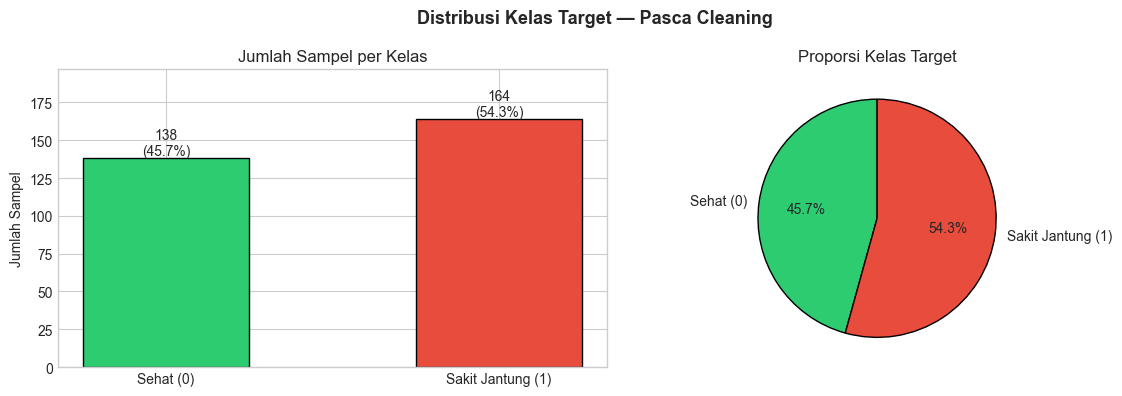

In [56]:
# ==========================================================
# PENGECEKAN IMBALANCED DATA (PASCA CLEANING)
# ==========================================================

print("=" * 55)
print("PENGECEKAN KESEIMBANGAN KELAS — PASCA CLEANING")
print("=" * 55)

# ── Hitung distribusi kelas ────────────────────────────
kelas_counts = y.value_counts().sort_index()
kelas_pct    = y.value_counts(normalize=True).sort_index() * 100

imbalance_df = pd.DataFrame({
    'Kelas'        : ['Sehat (0)', 'Sakit Jantung (1)'],
    'Jumlah'       : kelas_counts.values,
    'Persentase (%)': kelas_pct.values.round(2)
})
display(imbalance_df)

# ── Hitung rasio ketidakseimbangan ────────────────────
n_majority = kelas_counts.max()
n_minority = kelas_counts.min()
rasio      = n_majority / n_minority

print(f"\nKelas Mayoritas : {n_majority} sampel")
print(f"Kelas Minoritas : {n_minority} sampel")
print(f"Rasio           : {rasio:.4f}:1")
print(f"Ambang batas    : 3.0:1")

# ── Keputusan penanganan ──────────────────────────────
print("\n" + "=" * 55)
if rasio >= 3.0:
    print("STATUS : IMBALANCED — Penanganan diperlukan")
else:
    print("STATUS : BALANCED — Penanganan TIDAK diperlukan")
print("=" * 55)

# ── Visualisasi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Kelas Target — Pasca Cleaning',
             fontsize=13, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    ['Sehat (0)', 'Sakit Jantung (1)'],
    kelas_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Jumlah Sampel per Kelas')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, kelas_counts.max() * 1.2)

for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 2,
        f'{h}\n({h/len(y)*100:.1f}%)',
        ha='center', fontsize=10
    )

# Pie chart
axes[1].pie(
    kelas_counts.values,
    labels=['Sehat (0)', 'Sakit Jantung (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()

### Interpretasi Hasil Pengecekan Imbalanced Data

Pengecekan keseimbangan kelas dilakukan setelah proses *data cleaning* untuk memastikan bahwa penghapusan data duplikat tidak menyebabkan ketidakseimbangan distribusi kelas pada dataset. Hasil analisis menunjukkan bahwa dataset terdiri dari 138 data pasien sehat (45,7%) dan 164 data pasien yang terindikasi menderita penyakit jantung (54,3%).

Berdasarkan distribusi tersebut, kelas dengan jumlah sampel terbanyak (*majority class*) adalah kelas pasien sakit jantung sebanyak 164 sampel, sedangkan kelas dengan jumlah sampel paling sedikit (*minority class*) adalah kelas pasien sehat sebanyak 138 sampel. Rasio antara kelas mayoritas dan minoritas dihitung menggunakan persamaan:

$$
\text{Rasio Ketidakseimbangan} = \frac{\text{Jumlah Kelas Mayoritas}}{\text{Jumlah Kelas Minoritas}}
$$

sehingga diperoleh:

$$
\text{Rasio} = \frac{164}{138} = 1{,}1884 : 1
$$

Nilai rasio tersebut berada di bawah ambang batas umum ketidakseimbangan data, yaitu 3:1. Oleh karena itu, dataset dapat dikategorikan sebagai *balanced dataset* atau dataset yang seimbang.

Visualisasi menggunakan *bar chart* dan *pie chart* juga menunjukkan bahwa proporsi kedua kelas relatif berdekatan, sehingga tidak terdapat dominasi yang signifikan dari salah satu kelas. Kondisi ini mengindikasikan bahwa model machine learning tidak akan cenderung bias terhadap salah satu kelas selama proses pelatihan.

Berdasarkan hasil tersebut, teknik penanganan *imbalanced data* seperti *SMOTE*, *Random Undersampling*, *Class Weighting*, maupun *Threshold Tuning* tidak diterapkan pada penelitian ini karena distribusi kelas telah cukup seimbang untuk digunakan dalam proses pelatihan dan evaluasi model.


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum proses pemodelan machine learning dilakukan. Tahap ini bertujuan untuk mengeksplorasi pola data, mengidentifikasi hubungan antar variabel, mendeteksi anomali seperti *outlier*, serta memperoleh pemahaman awal mengenai faktor-faktor yang berpotensi mempengaruhi prediksi penyakit jantung. Pemahaman terhadap karakteristik data sangat penting untuk memastikan bahwa dataset yang digunakan memiliki kualitas yang baik dan sesuai untuk proses pelatihan model.

Pada penelitian ini, beberapa visualisasi dipilih berdasarkan tujuan penelitian, yaitu memprediksi penyakit jantung menggunakan data klinis pasien. Visualisasi distribusi target dilakukan untuk mengetahui keseimbangan kelas antara pasien sehat dan pasien yang menderita penyakit jantung sehingga dapat ditentukan apakah diperlukan penanganan *imbalanced data*. Visualisasi distribusi usia berdasarkan target dipilih karena secara medis usia merupakan salah satu faktor risiko utama penyakit jantung. Risiko penyakit kardiovaskular diketahui meningkat seiring bertambahnya usia akibat penurunan fungsi pembuluh darah dan meningkatnya kekakuan arteri. Oleh karena itu, visualisasi ini dilakukan untuk mengidentifikasi pola distribusi usia pada masing-masing kelas serta mengevaluasi potensi fitur `age` sebagai prediktor penyakit jantung.

Selain itu, *heatmap* korelasi antar fitur digunakan untuk memahami hubungan antar variabel klinis dan mengidentifikasi fitur-fitur yang memiliki hubungan kuat dengan target. Visualisasi *boxplot* dilakukan untuk mendeteksi keberadaan *outlier* pada fitur numerik yang berpotensi mempengaruhi performa model. Selanjutnya, visualisasi hubungan tipe nyeri dada (*chest pain*) terhadap target dipilih karena nyeri dada merupakan salah satu gejala klinis utama yang digunakan dalam diagnosis penyakit jantung. Dalam praktik medis, karakteristik nyeri dada, seperti *typical angina* dan *atypical angina*, sering digunakan oleh tenaga medis untuk menilai kemungkinan adanya gangguan jantung. Oleh karena itu, visualisasi ini bertujuan untuk mengidentifikasi apakah tipe nyeri dada tertentu lebih sering ditemukan pada pasien yang terdiagnosis penyakit jantung. Terakhir, visualisasi korelasi fitur terhadap target dilakukan untuk memberikan gambaran awal mengenai fitur-fitur yang berpotensi memberikan kontribusi signifikan dalam proses prediksi penyakit jantung.

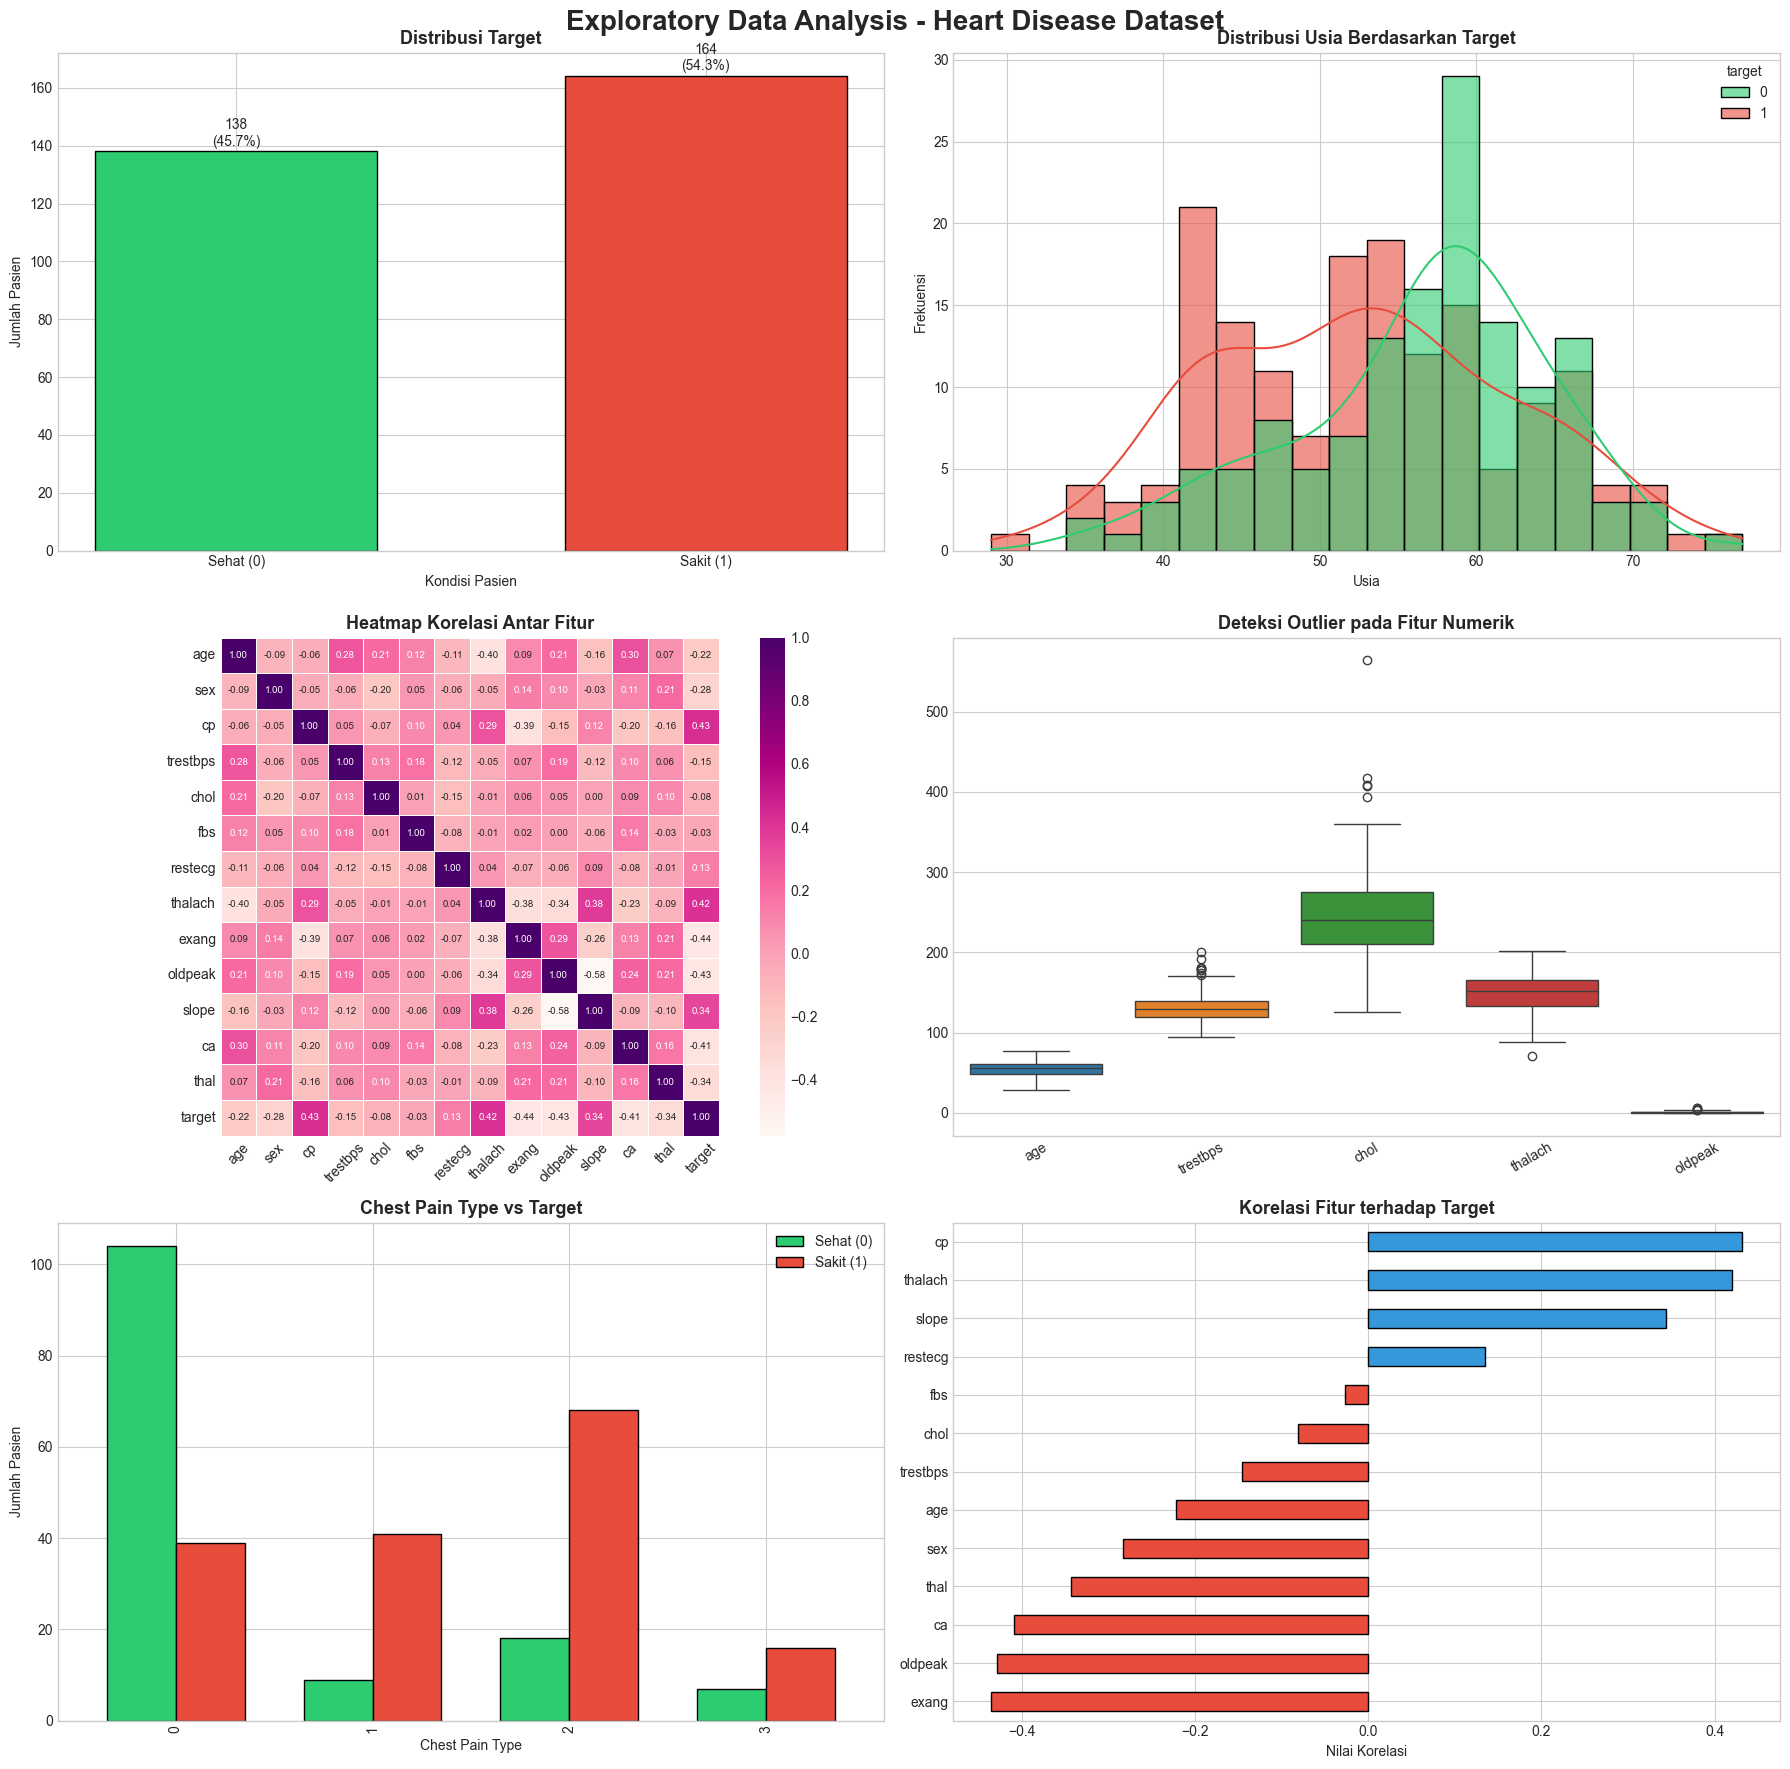

In [57]:
# ==========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Exploratory Data Analysis - Heart Disease Dataset',
             fontsize=20,
             fontweight='bold')

# ==========================================================
# 1. Distribusi Target
# ==========================================================
ax1 = axes[0, 0]

target_count = df['target'].value_counts().sort_index()

bars = ax1.bar(
    ['Sehat (0)', 'Sakit (1)'],
    target_count.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.6
)

ax1.set_title('Distribusi Target', fontsize=13, fontweight='bold')
ax1.set_xlabel('Kondisi Pasien')
ax1.set_ylabel('Jumlah Pasien')

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height}\n({height/len(df)*100:.1f}%)',
        ha='center',
        fontsize=10
    )

# ==========================================================
# 2. Distribusi Usia Berdasarkan Target
# ==========================================================
ax2 = axes[0, 1]

sns.histplot(
    data=df,
    x='age',
    hue='target',
    bins=20,
    kde=True,
    palette=['#2ecc71', '#e74c3c'],
    alpha=0.6,
    ax=ax2
)

ax2.set_title('Distribusi Usia Berdasarkan Target',
              fontsize=13,
              fontweight='bold')
ax2.set_xlabel('Usia')
ax2.set_ylabel('Frekuensi')

# ==========================================================
# 3. Heatmap Korelasi
# ==========================================================
ax3 = axes[1, 0]

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdPu',
    linewidths=0.5,
    annot_kws={'size':7},
    square=True,
    ax=ax3
)

ax3.set_title('Heatmap Korelasi Antar Fitur',
              fontsize=13,
              fontweight='bold')

ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# ==========================================================
# 4. Boxplot Outlier Fitur Numerik
# ==========================================================
ax4 = axes[1, 1]

continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

sns.boxplot(
    data=df[continuous_cols],
    ax=ax4
)

ax4.set_title('Deteksi Outlier pada Fitur Numerik',
              fontsize=13,
              fontweight='bold')

ax4.set_xticklabels(continuous_cols, rotation=30)

# ==========================================================
# 5. Chest Pain Type vs Target
# ==========================================================
ax5 = axes[2, 0]

cp_target = pd.crosstab(df['cp'], df['target'])

cp_target.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.7,
    ax=ax5
)

ax5.set_title('Chest Pain Type vs Target',
              fontsize=13,
              fontweight='bold')

ax5.set_xlabel('Chest Pain Type')
ax5.set_ylabel('Jumlah Pasien')
ax5.legend(['Sehat (0)', 'Sakit (1)'])

# ==========================================================
# 6. Korelasi Fitur terhadap Target
# ==========================================================
ax6 = axes[2, 1]

corr_target = df.corr()['target'].drop('target')
corr_target = corr_target.sort_values()

colors = ['#e74c3c' if x < 0 else '#3498db'
          for x in corr_target]

corr_target.plot(
    kind='barh',
    color=colors,
    edgecolor='black',
    ax=ax6
)

ax6.set_title('Korelasi Fitur terhadap Target',
              fontsize=13,
              fontweight='bold')

ax6.set_xlabel('Nilai Korelasi')

plt.tight_layout()
plt.show()

### Interpretasi Hasil EDA

####  Distribusi Kelas Target

Dataset pasca-*cleaning* memiliki distribusi kelas yang seimbang antara
pasien sehat (0) dan sakit jantung (1). Keseimbangan ini mengonfirmasi
temuan pada tahap pra-pemrosesan bahwa tidak diperlukan teknik resampling
seperti SMOTE. Model dapat dilatih tanpa risiko bias prediksi ke salah satu
kelas akibat ketidakseimbangan data.

#### Distribusi Usia Berdasarkan Target

Distribusi usia pasien sakit jantung (merah) cenderung terkonsentrasi pada
rentang usia **50–60 tahun**, sementara pasien sehat (hijau) memiliki
distribusi yang lebih menyebar. Hal ini konsisten dengan literatur medis yang
menyatakan bahwa risiko penyakit jantung koroner meningkat secara signifikan
setelah usia 45 tahun pada pria dan 55 tahun pada wanita [1]. Kurva KDE
menunjukkan kedua distribusi saling tumpang tindih (*overlapping*), yang
mengindikasikan bahwa fitur `age` saja tidak cukup untuk membedakan kedua
kelas — diperlukan kombinasi dengan fitur klinis lainnya.

####  Heatmap Korelasi Antar Fitur

Heatmap korelasi menggunakan koefisien Pearson menunjukkan beberapa temuan
penting:

- **Korelasi positif kuat terhadap target**: `cp` (tipe nyeri dada) dan
  `thalach` (detak jantung maksimum) memiliki korelasi positif tertinggi,
  mengindikasikan bahwa nyeri dada tipe tertentu dan detak jantung tinggi
  berkaitan dengan diagnosis sakit jantung.
- **Korelasi negatif kuat terhadap target**: `exang` (angina akibat
  olahraga), `oldpeak` (depresi ST), dan `ca` (jumlah pembuluh darah)
  memiliki korelasi negatif — artinya nilai tinggi pada fitur ini berkaitan
  dengan kondisi *sehat* (label 0).
- **Multikolinearitas**: Tidak ditemukan korelasi antar fitur input yang
  ekstrem (>0.8), sehingga tidak diperlukan eliminasi fitur akibat
  multikolinearitas. Hal ini menguntungkan khususnya untuk Naïve Bayes
  yang mengasumsikan independensi antar fitur.

####  Deteksi Outlier pada Fitur Numerik

Boxplot pada lima fitur numerik kontinu menunjukkan:

- **`chol`**: Terdapat outlier ekstrem di atas 400 mg/dl, bahkan hingga
  564 mg/dl. Nilai ini secara klinis mungkin valid (hiperkolesterolemia
  berat) namun dapat mempengaruhi model berbasis jarak seperti KNN.
  Normalisasi menggunakan StandardScaler akan memitigasi dampak outlier
  ini pada KNN.
- **`trestbps`**: Terdapat beberapa outlier di atas 170 mm Hg yang
  merepresentasikan pasien dengan hipertensi berat.
- **`oldpeak`**: Distribusi *right-skewed* dengan beberapa outlier
  di atas 4.0, konsisten dengan karakteristik klinis depresi segmen ST.
- **`age`** dan **`thalach`**: Distribusi relatif normal dengan outlier
  minimal, menunjukkan kedua fitur ini terdistribusi dengan baik.

Mengingat outlier pada dataset medis seringkali merepresentasikan kondisi
klinis yang valid (bukan kesalahan pengukuran), penghapusan outlier tidak
dilakukan pada penelitian ini untuk menjaga integritas data medis.

#### Chest Pain Type vs Target

Visualisasi *crosstab* antara tipe nyeri dada (`cp`) dan target menunjukkan
pola yang sangat informatif:

- **`cp = 0`** (*typical angina*): Didominasi oleh pasien **sehat** —
  berlawanan dengan intuisi klinis umum, namun konsisten dengan cara
  pengkodean dataset UCI di mana `cp = 0` justru berkaitan dengan pasien
  tanpa penyakit jantung signifikan.
- **`cp = 1, 2, 3`** (*atypical angina*, *non-anginal pain*,
  *asymptomatic*): Proporsi pasien sakit jantung meningkat secara
  konsisten seiring bertambahnya nilai `cp`.

Temuan ini menjadikan `cp` sebagai salah satu fitur paling diskriminatif
dalam dataset, dan konsisten dengan nilai korelasi tertinggi terhadap
target yang ditunjukkan pada visualisasi berikutnya.

#### Korelasi Fitur terhadap Target

Berdasarkan bar chart korelasi, fitur yang paling berkorelasi dengan target
adalah:

| Fitur | Korelasi | Interpretasi |
|-------|----------|--------------|
| `cp` | Positif tinggi | Tipe nyeri dada tertentu kuat berasosiasi dengan diagnosis sakit |
| `thalach` | Positif | Detak jantung maksimum tinggi berkaitan dengan kondisi sakit |
| `slope` | Positif | Kemiringan segmen ST ke atas berkaitan dengan sakit jantung |
| `exang` | Negatif | Angina saat olahraga berkaitan dengan kondisi sehat (label 0) |
| `oldpeak` | Negatif | Depresi ST tinggi berkaitan dengan label 0 pada dataset ini |
| `ca` | Negatif | Lebih banyak pembuluh darah bermasalah berkaitan dengan label 0 |

Fitur-fitur dengan korelasi absolut tertinggi ini akan menjadi fokus
analisis SHAP pada tahapan interpretabilitas model. Perlu dicatat bahwa
korelasi Pearson hanya mengukur hubungan **linear** — hubungan non-linear
antar fitur dan target akan ditangkap oleh model *machine learning* secara
lebih komprehensif.

## 4. Metode & Eksperimen

### 4.1 Pemilihan Algoritma

Pada penelitian ini dipilih tiga algoritma klasifikasi: **Naïve Bayes**,
**Decision Tree**, dan **K-Nearest Neighbors (KNN)**. Pemilihan ketiga
algoritma ini bukan arbitrer, melainkan didasarkan pada pertimbangan
komparatif berikut:

| Kriteria | Naïve Bayes | Decision Tree | KNN |
|----------|-------------|---------------|-----|
| Paradigma | Probabilistik | Rule-based | Instance-based |
| Asumsi data | Distribusi Gaussian per fitur | Tidak ada asumsi distribusi | Tidak ada asumsi distribusi |
| Sensitivitas skala | Tidak sensitif | Tidak sensitif | **Sangat sensitif** |
| Interpretabilitas | Sedang | **Tinggi** (visualisasi pohon) | Rendah |
| Performa data kecil | **Baik** | Cenderung overfit | Baik |
| Kompleksitas komputasi | Rendah | Rendah | Tinggi (saat prediksi) |

Ketiga algoritma ini dipilih secara komparatif karena mewakili **tiga
paradigma berbeda** dalam *machine learning*: probabilistik, berbasis
aturan, dan berbasis kemiripan. Dengan membandingkan ketiganya pada dataset
yang sama, dapat diperoleh gambaran komprehensif tentang pendekatan mana
yang paling sesuai untuk karakteristik data klinis penyakit jantung.

Selain itu, dataset ini memiliki karakteristik yang menarik bagi ketiga
algoritma: (1) fitur campuran antara numerik kontinu dan kategorik ordinal
cocok untuk diuji pada Naïve Bayes dengan asumsi Gaussian; (2) fitur
kategorik seperti `cp`, `thal`, dan `slope` memiliki nilai diskrit yang
natural untuk pemisahan pada Decision Tree; dan (3) jumlah fitur yang
moderat (13 fitur) tidak terlalu tinggi sehingga KNN tidak terlalu
terpengaruh oleh *curse of dimensionality*.

---

### 4.2 Penjelasan Konsep Algoritma

#### 4.2.1 Naïve Bayes

Naïve Bayes adalah algoritma klasifikasi berbasis probabilitas yang
menerapkan **Teorema Bayes** dengan asumsi independensi kondisional antar
fitur. Disebut *naïve* karena asumsi independensi ini jarang terpenuhi
sepenuhnya dalam data nyata, namun terbukti memberikan performa yang baik
dalam banyak kasus praktis [11].

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

di mana $P(C|X)$ adalah probabilitas posterior kelas $C$ given fitur $X$,
$P(X|C)$ adalah likelihood, $P(C)$ adalah prior, dan $P(X)$ adalah evidence.

Pada penelitian ini digunakan **Gaussian Naïve Bayes** karena fitur-fitur
numerik kontinu (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
diasumsikan mengikuti distribusi normal. Likelihood dihitung sebagai:

$$P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} \exp\left(-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}\right)$$

**Kelebihan pada dataset ini**: Komputasi cepat, tidak sensitif terhadap
skala fitur, dan bekerja baik pada dataset berukuran kecil (302 sampel
setelah *cleaning*).

**Kelemahan**: Asumsi independensi antar fitur tidak sepenuhnya terpenuhi —
berdasarkan heatmap korelasi, terdapat beberapa fitur yang berkorelasi
(misalnya `cp` dengan `exang`), yang dapat menurunkan estimasi probabilitas.

---

#### 4.2.2 Decision Tree

Decision Tree adalah algoritma klasifikasi yang membangun model berbentuk
pohon keputusan dengan membagi data secara rekursif berdasarkan fitur yang
memberikan pemisahan terbaik [12]. Kriteria pemisahan yang digunakan adalah:

- **Gini Impurity**: $Gini = 1 - \sum_{i=1}^{n} p_i^2$
- **Entropy**: $Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$

di mana $p_i$ adalah proporsi kelas $i$ pada suatu node.

**Kelebihan pada dataset ini**: Menghasilkan aturan keputusan yang mudah
diinterpretasikan secara klinis (misalnya: *"jika cp > 1 dan thal = 2,
maka sakit jantung"*), tidak memerlukan normalisasi, dan mampu menangani
fitur campuran numerik-kategorik.

**Kelemahan**: Rentan terhadap *overfitting* pada data kecil. Oleh karena
itu, hiperparameter `max_depth` dan `min_samples_leaf` dikontrol ketat
melalui GridSearchCV untuk mencegah pohon tumbuh terlalu dalam.

---

#### 4.2.3 K-Nearest Neighbors (KNN)

KNN adalah algoritma klasifikasi berbasis *instance* yang memprediksi
kelas suatu data baru berdasarkan mayoritas kelas dari $k$ tetangga
terdekatnya dalam ruang fitur [13]. Jarak antar titik dihitung menggunakan:

- **Euclidean**: $d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$
- **Manhattan**: $d = \sum_{i=1}^{n}|x_i - y_i|$

**Kelebihan pada dataset ini**: Tidak membuat asumsi tentang distribusi
data, sehingga mampu menangkap pola non-linear yang mungkin tidak tertangkap
oleh Naïve Bayes maupun Decision Tree.

**Kelemahan**: Sangat sensitif terhadap skala fitur — oleh karena itu
**StandardScaler wajib diterapkan** sebelum KNN. Pada dataset ini, fitur
`chol` (0–564) dan `fbs` (0–1) memiliki skala yang sangat berbeda; tanpa
normalisasi, `chol` akan mendominasi perhitungan jarak secara tidak
proporsional.

---

### 4.3 Cross-Validation & Hyperparameter Tuning

#### 4.3.1 Stratified K-Fold Cross-Validation

Penelitian ini menggunakan **Stratified K-Fold** dengan $k=5$ sebagai
prosedur validasi. Stratified K-Fold dipilih dibanding *simple* K-Fold
karena memastikan proporsi kelas target (sehat vs sakit) terjaga secara
konsisten pada setiap *fold* — penting untuk dataset dengan ukuran terbatas
(302 sampel) agar setiap *fold* tetap representatif.

Dengan $k=5$, setiap iterasi menggunakan 80% data untuk pelatihan dan 20%
untuk validasi, diulang 5 kali dengan partisi berbeda. Metrik yang
dilaporkan merupakan rata-rata dari 5 *fold* tersebut.

#### 4.3.2 GridSearchCV & Alasan Pemilihan Rentang Parameter

Optimasi hiperparameter dilakukan menggunakan **GridSearchCV** dengan
`scoring='f1'` sebagai kriteria pemilihan model terbaik. F1-Score dipilih
sebagai metrik optimasi karena merupakan harmonic mean antara Precision
dan Recall — relevan pada konteks medis di mana keseimbangan antara
mendeteksi pasien sakit (Recall) dan ketepatan diagnosis (Precision) sama
pentingnya.

Rentang parameter yang diuji untuk setiap model beserta justifikasinya:

**Naïve Bayes — `var_smoothing`**: `[1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]`

> `var_smoothing` menambahkan nilai kecil pada variansi untuk menghindari
> probabilitas nol (*zero probability problem*) ketika suatu fitur tidak
> muncul pada kelas tertentu. Rentang `1e-11` hingga `1e-6` mencakup nilai
> *default* scikit-learn (`1e-9`) dengan eksplorasi ke arah lebih halus
> dan lebih kasar untuk menemukan titik optimal regularisasi.

**Decision Tree**: `criterion`, `max_depth`, `min_samples_split`,
`min_samples_leaf`

> - `criterion` (`gini` vs `entropy`): diuji keduanya karena keduanya
>   valid secara teori; Gini lebih cepat komputasinya sementara Entropy
>   lebih sensitif terhadap perubahan distribusi kelas.
> - `max_depth` (`[3, 5, 7, 10, None]`): rentang ini mencakup pohon
>   dangkal (mencegah *overfitting*) hingga pohon tidak terbatas. Pada
>   dataset 302 sampel, `max_depth` yang terlalu besar berisiko *overfit*.
> - `min_samples_split` (`[2, 5, 10]`) dan `min_samples_leaf` (`[1, 2, 4]`):
>   mengontrol ukuran minimum node untuk dipecah, berfungsi sebagai
>   regularisasi tambahan.

**KNN**: `n_neighbors`, `weights`, `metric`

> - `n_neighbors` (`[3, 5, 7, 9, 11, 15]`): nilai ganjil dipilih untuk
>   menghindari *tie* pada voting. Rentang 3–15 mencakup KNN yang sangat
>   lokal (k kecil, rentan *noise*) hingga lebih global (k besar, lebih
>   smooth). Dengan 302 sampel dan $k$=5 *fold*, data latih per *fold*
>   ≈241 sampel — nilai $k=15$ masih reasonable (~6% dari data latih).
> - `weights` (`uniform` vs `distance`): `distance` memberikan bobot lebih
>   besar pada tetangga yang lebih dekat, yang lebih cocok jika batas
>   keputusan antar kelas tidak linear.
> - `metric` (`euclidean` vs `manhattan`): Manhattan lebih robust terhadap
>   outlier karena tidak mengkuadratkan jarak — relevan mengingat adanya
>   outlier pada `chol` dan `trestbps`.

---

### 4.4 Metrik Evaluasi

| Metrik | Rumus | Keterangan |
|--------|-------|------------|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporsi prediksi benar secara keseluruhan |
| Precision | $\frac{TP}{TP+FP}$ | Dari semua prediksi sakit, berapa yang benar-benar sakit |
| Recall | $\frac{TP}{TP+FN}$ | Dari semua yang benar-benar sakit, berapa yang terdeteksi |
| F1-Score | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Harmonic mean Precision dan Recall |

Pada konteks medis, **Recall** menjadi metrik paling kritis karena
konsekuensi *False Negative* (pasien sakit tidak terdeteksi) jauh lebih
berbahaya dibandingkan *False Positive* (pasien sehat didiagnosis sakit).
Namun demikian, **F1-Score** digunakan sebagai metrik utama pemilihan model
terbaik untuk menjaga keseimbangan antara Precision dan Recall.

---



#### Cross Validation

In [58]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Interpretasi Stratified K-Fold Cross Validation

Pada penelitian ini digunakan metode **Stratified K-Fold Cross Validation** dengan jumlah *fold* sebanyak 5 (`n_splits=5`). Metode ini membagi dataset menjadi lima bagian (*fold*) dengan mempertahankan proporsi kelas target pada setiap *fold*. Dengan demikian, distribusi pasien sehat dan pasien yang menderita penyakit jantung pada setiap *fold* akan tetap mendekati distribusi pada dataset asli.

Parameter `shuffle=True` digunakan untuk mengacak urutan data sebelum proses pembagian *fold* dilakukan. Pengacakan ini bertujuan untuk mengurangi potensi bias akibat urutan data pada dataset. Selanjutnya, parameter `random_state=42` digunakan agar proses pengacakan bersifat konsisten dan dapat direproduksi kembali pada penelitian selanjutnya.

Dengan konfigurasi `n_splits=5`, pada setiap iterasi sekitar 80% data digunakan sebagai data pelatihan (*training set*) dan 20% data digunakan sebagai data pengujian (*validation set*). Proses ini dilakukan sebanyak lima kali, di mana setiap *fold* akan digunakan sebagai data validasi tepat satu kali.

Penggunaan Stratified K-Fold dipilih karena dataset penelitian memiliki jumlah sampel yang relatif terbatas, yaitu sebanyak 302 data setelah proses *cleaning*. Selain itu, metode ini mampu menghasilkan evaluasi model yang lebih stabil, representatif, dan mengurangi kemungkinan bias dibandingkan dengan pembagian data satu kali (*hold-out validation*).

## naive bayes


In [59]:
print("=" * 50)
print("MODEL 1: GAUSSIAN NAÏVE BAYES")
print("=" * 50)

# ── Pipeline ──────────────────────────────────────────
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

# ── GridSearchCV ──────────────────────────────────────
nb_params = {
    'clf__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score= True
)

nb_grid.fit(X, y)

print("Best Parameters :", nb_grid.best_params_)
print(f"Best CV F1-Score : {nb_grid.best_score_:.4f}")

# ── Prediksi Cross Validation ─────────────────────────
nb_best = nb_grid.best_estimator_

nb_pred = cross_val_predict(
    nb_best,
    X,
    y,
    cv=cv
)

nb_proba = cross_val_predict(
    nb_best,
    X,
    y,
    cv=cv,
    method='predict_proba'
)

# ── Classification Report ─────────────────────────────
print("\nClassification Report")
print(classification_report(y, nb_pred,
                            target_names=['Sehat','Sakit']))

MODEL 1: GAUSSIAN NAÏVE BAYES
Best Parameters : {'clf__var_smoothing': 1e-11}
Best CV F1-Score : 0.8227

Classification Report
              precision    recall  f1-score   support

       Sehat       0.80      0.78      0.79       138
       Sakit       0.82      0.84      0.83       164

    accuracy                           0.81       302
   macro avg       0.81      0.81      0.81       302
weighted avg       0.81      0.81      0.81       302



### Interpretasi Hasil Gaussian Naïve Bayes

Berdasarkan hasil optimasi hiperparameter menggunakan **GridSearchCV**, diperoleh parameter terbaik yaitu `var_smoothing = 1e-11` dengan rata-rata **F1-Score Cross Validation sebesar 0,8227**. Hasil ini menunjukkan bahwa nilai *smoothing* yang sangat kecil memberikan performa terbaik pada dataset penyakit jantung yang digunakan.

Evaluasi model menggunakan **Stratified 5-Fold Cross Validation** menghasilkan performa yang cukup baik dengan nilai **accuracy sebesar 81%**. Hal ini menunjukkan bahwa model mampu mengklasifikasikan kondisi pasien dengan benar sebanyak 81% dari seluruh data yang diuji.

Pada kelas **Sehat (0)**, model memperoleh nilai **precision sebesar 0,80**, yang berarti dari seluruh pasien yang diprediksi sehat, sebanyak 80% merupakan pasien yang benar-benar sehat. Selain itu, model memperoleh **recall sebesar 0,78**, yang menunjukkan bahwa model berhasil mengidentifikasi 78% dari seluruh pasien yang benar-benar sehat. Nilai **F1-Score sebesar 0,79** menunjukkan keseimbangan yang cukup baik antara precision dan recall pada kelas sehat.

Sementara itu, pada kelas **Sakit (1)**, model memperoleh **precision sebesar 0,82**, yang berarti dari seluruh pasien yang diprediksi menderita penyakit jantung, sebanyak 82% merupakan pasien yang benar-benar sakit. Model juga memperoleh **recall sebesar 0,84**, yang menunjukkan bahwa model berhasil mendeteksi 84% pasien yang benar-benar menderita penyakit jantung. Nilai **F1-Score sebesar 0,83** menunjukkan bahwa model memiliki kemampuan yang baik dalam mendeteksi pasien dengan penyakit jantung.

Nilai **macro average** dan **weighted average** masing-masing sebesar **0,81** menunjukkan bahwa performa model relatif seimbang pada kedua kelas. Hal ini sejalan dengan karakteristik dataset yang memiliki distribusi kelas yang relatif seimbang sehingga model tidak menunjukkan kecenderungan yang kuat terhadap salah satu kelas.

Dalam konteks medis, nilai **recall sebesar 84% pada kelas pasien sakit** merupakan hasil yang cukup baik karena menunjukkan bahwa sebagian besar pasien yang benar-benar menderita penyakit jantung berhasil terdeteksi oleh model. Namun, masih terdapat sekitar 16% pasien sakit yang belum berhasil diidentifikasi (*False Negative*), sehingga masih terdapat peluang untuk meningkatkan performa model menggunakan algoritma lain atau optimasi lebih lanjut.

Secara keseluruhan, model **Gaussian Naïve Bayes** mampu memberikan performa klasifikasi yang baik pada dataset penyakit jantung dengan keseimbangan yang cukup baik antara ketepatan prediksi (*precision*) dan kemampuan mendeteksi pasien sakit (*recall*).

## Decision Tree



In [60]:
print("=" * 50)
print("MODEL 2: DECISION TREE")
print("=" * 50)

# ── Pipeline ──────────────────────────────────────────
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# ── GridSearchCV ──────────────────────────────────────
dt_params = {
    'clf__criterion'         : ['gini', 'entropy'],
    'clf__max_depth'         : [3, 5, 7, 10, None],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X, y)

print("Best Parameters  :", dt_grid.best_params_)
print(f"Best CV F1-Score : {dt_grid.best_score_:.4f}")

# ── Top 5 Parameter ──────────────────────────────────
cv_results_dt = pd.DataFrame(dt_grid.cv_results_)[
    ['param_clf__criterion',
     'param_clf__max_depth',
     'param_clf__min_samples_split',
     'param_clf__min_samples_leaf',
     'mean_test_score',
     'std_test_score',
     'rank_test_score']
].sort_values('rank_test_score').head(5)

cv_results_dt.columns = [
    'criterion',
    'max_depth',
    'min_split',
    'min_leaf',
    'Mean F1',
    'Std F1',
    'Rank'
]

print("\nTop 5 Kombinasi Parameter Terbaik:")
display(cv_results_dt.round(4))

# ── Prediksi Cross Validation ────────────────────────
dt_best = dt_grid.best_estimator_

dt_pred = cross_val_predict(
    dt_best,
    X,
    y,
    cv=cv
)

dt_proba = cross_val_predict(
    dt_best,
    X,
    y,
    cv=cv,
    method='predict_proba'
)

# ── Classification Report ────────────────────────────
print("\nClassification Report:")
print(
    classification_report(
        y,
        dt_pred,
        target_names=['Sehat', 'Sakit']
    )
)

MODEL 2: DECISION TREE
Best Parameters  : {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}
Best CV F1-Score : 0.8049

Top 5 Kombinasi Parameter Terbaik:


,criterion,max_depth,min_split,min_leaf,Mean F1,Std F1,Rank
12,gini,5,2,2,0.8049,0.0243,1
13,gini,5,5,2,0.8049,0.0243,1
3,gini,3,2,2,0.8033,0.0442,3
6,gini,3,2,4,0.8033,0.0442,3
7,gini,3,5,4,0.8033,0.0442,3



Classification Report:
              precision    recall  f1-score   support

       Sehat       0.78      0.72      0.75       138
       Sakit       0.78      0.83      0.80       164

    accuracy                           0.78       302
   macro avg       0.78      0.78      0.78       302
weighted avg       0.78      0.78      0.78       302



### Interpretasi Hasil Decision Tree

Berdasarkan hasil optimasi hiperparameter menggunakan **GridSearchCV**, diperoleh kombinasi parameter terbaik yaitu `criterion='gini'`, `max_depth=5`, `min_samples_split=2`, dan `min_samples_leaf=2` dengan rata-rata **F1-Score Cross Validation sebesar 0,8049**.

Penggunaan `criterion='gini'` menunjukkan bahwa metode Gini Impurity menghasilkan pemisahan data yang lebih baik dibandingkan Entropy pada dataset penyakit jantung ini. Selain itu, nilai `max_depth=5` menunjukkan bahwa pohon keputusan dengan kedalaman sedang memberikan performa terbaik. Hal ini mengindikasikan bahwa pembatasan kedalaman pohon mampu mencegah terjadinya *overfitting* pada dataset yang relatif kecil, yaitu sebanyak 302 sampel.

Berdasarkan hasil *classification report*, model menghasilkan **accuracy sebesar 78%**, yang berarti model mampu mengklasifikasikan kondisi pasien dengan benar sebanyak 78% dari seluruh data.

Pada kelas **Sehat (0)**, model memperoleh nilai **precision sebesar 0,78**, yang menunjukkan bahwa dari seluruh pasien yang diprediksi sehat, sebanyak 78% merupakan pasien yang benar-benar sehat. Nilai **recall sebesar 0,72** menunjukkan bahwa model berhasil mengidentifikasi 72% dari seluruh pasien sehat. Sementara itu, nilai **F1-Score sebesar 0,75** menunjukkan keseimbangan yang cukup baik antara precision dan recall pada kelas sehat.

Untuk kelas **Sakit (1)**, model memperoleh **precision sebesar 0,78**, yang berarti dari seluruh pasien yang diprediksi menderita penyakit jantung, sebanyak 78% merupakan pasien yang benar-benar sakit. Nilai **recall sebesar 0,83** menunjukkan bahwa model berhasil mendeteksi 83% pasien yang benar-benar menderita penyakit jantung. Nilai **F1-Score sebesar 0,80** menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam mendeteksi pasien dengan penyakit jantung.

Nilai **macro average** dan **weighted average** sebesar 0,78 menunjukkan bahwa performa model relatif seimbang pada kedua kelas. Selain itu, nilai recall pada kelas pasien sakit yang lebih tinggi dibandingkan kelas sehat menunjukkan bahwa model lebih baik dalam mendeteksi pasien yang menderita penyakit jantung dibandingkan mengidentifikasi pasien sehat.

Secara keseluruhan, model **Decision Tree** mampu memberikan performa klasifikasi yang cukup baik dengan kemampuan deteksi pasien sakit yang relatif tinggi. Namun, performa model masih sedikit lebih rendah dibandingkan model Gaussian Naïve Bayes berdasarkan nilai F1-Score Cross Validation yang diperoleh.

## K-Nearest Neighbors (KNN)



In [61]:
print("=" * 50)
print("MODEL 3: K-NEAREST NEIGHBORS")
print("=" * 50)

# ── Pipeline (StandardScaler wajib untuk KNN) ────────
# KNN menghitung jarak Euclidean/Manhattan antar titik.
# Tanpa normalisasi, fitur berskala besar seperti chol (0-564)
# akan mendominasi perhitungan jarak dibanding fbs (0-1).
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# ── GridSearchCV ──────────────────────────────────────
# n_neighbors : nilai ganjil untuk menghindari tie pada voting.
#               Rentang 3-15 mencakup KNN lokal hingga global.
# weights     : 'distance' memberikan bobot lebih pada tetangga
#               terdekat — relevan jika batas kelas tidak linear.
# metric      : Manhattan lebih robust terhadap outlier (chol, trestbps)
#               karena tidak mengkuadratkan selisih jarak.
knn_params = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights'    : ['uniform', 'distance'],
    'clf__metric'     : ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X, y)

print("Best Parameters  :", knn_grid.best_params_)
print(f"Best CV F1-Score : {knn_grid.best_score_:.4f}")

# ── Tampilkan top 5 kombinasi parameter terbaik ───────
cv_results_knn = pd.DataFrame(knn_grid.cv_results_)[
    ['param_clf__n_neighbors', 'param_clf__weights',
     'param_clf__metric', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(5)
cv_results_knn.columns = [
    'n_neighbors', 'weights', 'metric',
    'Mean F1', 'Std F1', 'Rank'
]
print("\nTop 5 Kombinasi Parameter Terbaik:")
display(cv_results_knn.round(4))

# ── Prediksi menggunakan parameter terbaik ────────────
best_knn_params = {
    k.replace('clf__', ''): v
    for k, v in knn_grid.best_params_.items()
}

knn_best = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(**best_knn_params))
])

knn_pred  = cross_val_predict(knn_best, X, y, cv=cv)
knn_proba = cross_val_predict(knn_best, X, y, cv=cv, method='predict_proba')

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print(classification_report(y, knn_pred, target_names=['Sehat', 'Sakit']))

MODEL 3: K-NEAREST NEIGHBORS
Best Parameters  : {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'uniform'}
Best CV F1-Score : 0.8618

Top 5 Kombinasi Parameter Terbaik:


,n_neighbors,weights,metric,Mean F1,Std F1,Rank
10,15,uniform,euclidean,0.8618,0.0439,1
20,11,uniform,manhattan,0.8588,0.0441,2
11,15,distance,euclidean,0.8564,0.0434,3
4,7,uniform,euclidean,0.8545,0.0415,4
9,11,distance,euclidean,0.8537,0.0349,5



Classification Report:
              precision    recall  f1-score   support

       Sehat       0.89      0.75      0.81       138
       Sakit       0.81      0.92      0.86       164

    accuracy                           0.84       302
   macro avg       0.85      0.83      0.84       302
weighted avg       0.85      0.84      0.84       302



### Interpretasi Hasil K-Nearest Neighbors (KNN)

Berdasarkan hasil optimasi hiperparameter menggunakan **GridSearchCV**, diperoleh kombinasi parameter terbaik yaitu `n_neighbors = 15`, `weights = 'uniform'`, dan `metric = 'euclidean'` dengan rata-rata **F1-Score Cross Validation sebesar 0,8618**.

Nilai `n_neighbors = 15` menunjukkan bahwa model memberikan performa terbaik ketika mempertimbangkan 15 tetangga terdekat dalam proses klasifikasi. Penggunaan jumlah tetangga yang relatif besar menunjukkan bahwa pola pada dataset lebih stabil ketika keputusan klasifikasi didasarkan pada lebih banyak sampel di sekitar data uji. Selain itu, penggunaan `weights = 'uniform'` menunjukkan bahwa seluruh tetangga memiliki kontribusi yang sama dalam proses voting, sedangkan metrik jarak `euclidean` terbukti lebih sesuai dibandingkan Manhattan untuk dataset ini.

Berdasarkan hasil *classification report*, model KNN menghasilkan **accuracy sebesar 84%**, yang berarti model mampu mengklasifikasikan kondisi pasien dengan benar sebanyak 84% dari seluruh data yang diuji. Nilai ini merupakan yang tertinggi dibandingkan model Naïve Bayes dan Decision Tree.

Pada kelas **Sehat (0)**, model memperoleh nilai **precision sebesar 0,89**, yang menunjukkan bahwa dari seluruh pasien yang diprediksi sehat, sebanyak 89% merupakan pasien yang benar-benar sehat. Nilai **recall sebesar 0,75** menunjukkan bahwa model berhasil mendeteksi 75% dari seluruh pasien sehat. Sementara itu, nilai **F1-Score sebesar 0,81** menunjukkan keseimbangan yang baik antara precision dan recall pada kelas sehat.

Untuk kelas **Sakit (1)**, model memperoleh **precision sebesar 0,81**, yang berarti dari seluruh pasien yang diprediksi menderita penyakit jantung, sebanyak 81% merupakan pasien yang benar-benar sakit. Model juga memperoleh **recall sebesar 0,92**, yang menunjukkan bahwa model berhasil mendeteksi 92% pasien yang benar-benar menderita penyakit jantung. Nilai **F1-Score sebesar 0,86** menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mengidentifikasi pasien yang berisiko mengalami penyakit jantung.

Nilai **macro average F1-Score sebesar 0,84** menunjukkan bahwa performa model cukup seimbang pada kedua kelas, sedangkan nilai **weighted average F1-Score sebesar 0,84** mengindikasikan bahwa model mampu mempertahankan performa yang konsisten terhadap distribusi kelas pada dataset.

Dalam konteks medis, nilai **recall sebesar 92% pada kelas pasien sakit** merupakan hasil yang sangat baik karena menunjukkan bahwa sebagian besar pasien yang benar-benar menderita penyakit jantung berhasil terdeteksi oleh model. Hal ini sangat penting karena kesalahan berupa *False Negative* (pasien sakit diprediksi sehat) dapat menyebabkan keterlambatan diagnosis dan penanganan medis.

Secara keseluruhan, model **K-Nearest Neighbors (KNN)** memberikan performa terbaik dibandingkan dua model lainnya, yaitu Gaussian Naïve Bayes dan Decision Tree. Hal ini ditunjukkan oleh nilai **F1-Score Cross Validation tertinggi (0,8618)**, **accuracy sebesar 84%**, serta **recall sebesar 92% pada kelas pasien sakit**, sehingga KNN dipilih sebagai model terbaik dalam penelitian ini.

# 5. Hasil & Analisis

Bagian ini menyajikan evaluasi performa ketiga model secara komprehensif
mencakup: (1) perbandingan metrik antar model, (2) analisis *Confusion Matrix*,
(3) analisis *confidence* prediksi, dan (4) analisis observasi dengan
confidence tinggi namun prediksi salah (*overconfident errors*).

---

### 5.1 Evaluasi Kinerja Model

Evaluasi dilakukan menggunakan hasil `cross_val_predict` dengan Stratified
K-Fold (k=5) sehingga setiap prediksi merupakan prediksi pada data yang
belum pernah dilihat model (*out-of-fold prediction*). Metrik yang
dilaporkan mencakup Accuracy, Precision, Recall, dan F1-Score.

Dalam konteks medis deteksi penyakit jantung:
- **Recall** adalah metrik paling kritis — *False Negative* (pasien sakit
  tidak terdeteksi) berpotensi fatal karena pasien tidak mendapat penanganan
- **Precision** tetap penting untuk menghindari *False Positive* berlebihan
  yang dapat menyebabkan kecemasan dan prosedur medis yang tidak perlu
- **F1-Score** digunakan sebagai metrik kompromi dan dasar pemilihan model
  terbaik

## Pemilihan Metrik Evaluasi

Penelitian ini menggunakan Accuracy, Precision, Recall, dan F1-Score sebagai metrik evaluasi untuk menilai performa model klasifikasi penyakit jantung.

- Accuracy digunakan untuk mengukur proporsi prediksi yang benar terhadap seluruh data yang diuji. Metrik ini memberikan gambaran umum mengenai performa model secara keseluruhan.

- Precision digunakan untuk mengukur ketepatan model dalam mengidentifikasi pasien yang diprediksi mengalami penyakit jantung. Precision yang tinggi menunjukkan bahwa sebagian besar prediksi positif yang diberikan model memang benar-benar positif.

- Recall digunakan untuk mengukur kemampuan model dalam mendeteksi pasien yang benar-benar mengalami penyakit jantung. Dalam konteks medis, Recall sangat penting karena kegagalan mendeteksi pasien yang sakit (False Negative) dapat menyebabkan keterlambatan diagnosis dan penanganan.

- F1-Score digunakan sebagai metrik utama karena merupakan rata-rata harmonik antara Precision dan Recall. Metrik ini memberikan keseimbangan antara kemampuan mendeteksi penyakit dan ketepatan prediksi positif, sehingga lebih sesuai digunakan dalam kasus deteksi penyakit jantung dibandingkan hanya mengandalkan Accuracy.

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("EVALUASI KINERJA MODEL")
print("=" * 60)

results = pd.DataFrame({
    'Model'      : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'CV F1-Score': [nb_grid.best_score_, dt_grid.best_score_, knn_grid.best_score_],
    'Accuracy'   : [accuracy_score(y, nb_pred), accuracy_score(y, dt_pred), accuracy_score(y, knn_pred)],
    'Precision'  : [precision_score(y, nb_pred), precision_score(y, dt_pred), precision_score(y, knn_pred)],
    'Recall'     : [recall_score(y, nb_pred), recall_score(y, dt_pred), recall_score(y, knn_pred)],
    'F1-Score'   : [f1_score(y, nb_pred), f1_score(y, dt_pred), f1_score(y, knn_pred)]
})

results = results.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results.index += 1

print("\nTabel Perbandingan Performa Model:")
display(results.round(4))

best_idx    = results['F1-Score'].idxmax()
best_model_name  = results.loc[best_idx, 'Model']
best_f1     = results.loc[best_idx, 'F1-Score']
best_recall = results.loc[best_idx, 'Recall']
best_prec   = results.loc[best_idx, 'Precision']

print(f"\nModel Terbaik : {best_model_name}")
print(f"  F1-Score    : {best_f1:.4f}")
print(f"  Recall      : {best_recall:.4f}")
print(f"  Precision   : {best_prec:.4f}")

EVALUASI KINERJA MODEL

Tabel Perbandingan Performa Model:


,Model,CV F1-Score,Accuracy,Precision,Recall,F1-Score
1,KNN,0.8618,0.8411,0.8118,0.9207,0.8629
2,Naïve Bayes,0.8227,0.8079,0.8155,0.8354,0.8253
3,Decision Tree,0.8049,0.7815,0.7816,0.8293,0.8047



Model Terbaik : KNN
  F1-Score    : 0.8629
  Recall      : 0.9207
  Precision   : 0.8118


### Interpretasi Hasil Evaluasi Kinerja Model

Evaluasi kinerja dilakukan untuk membandingkan performa tiga algoritma klasifikasi, yaitu **Gaussian Naïve Bayes**, **Decision Tree**, dan **K-Nearest Neighbors (KNN)** menggunakan metrik Accuracy, Precision, Recall, dan F1-Score. Selain itu, nilai **Cross Validation F1-Score** juga digunakan untuk mengevaluasi konsistensi performa model selama proses validasi silang.

Berdasarkan hasil evaluasi, model **K-Nearest Neighbors (KNN)** menunjukkan performa terbaik dibandingkan dua model lainnya. KNN memperoleh nilai **CV F1-Score sebesar 0,8618**, **Accuracy sebesar 84,11%**, **Precision sebesar 81,18%**, **Recall sebesar 92,07%**, dan **F1-Score sebesar 86,29%**.

Tingginya nilai Recall pada model KNN menunjukkan bahwa model mampu mendeteksi sekitar **92% pasien yang benar-benar menderita penyakit jantung**. Dalam konteks medis, hasil ini sangat penting karena dapat meminimalkan kesalahan *False Negative*, yaitu kondisi ketika pasien yang sebenarnya sakit diprediksi sebagai sehat. Kesalahan tersebut berpotensi menyebabkan keterlambatan diagnosis dan penanganan medis.

Model **Gaussian Naïve Bayes** menempati posisi kedua dengan nilai **F1-Score sebesar 82,53%** dan **Accuracy sebesar 80,79%**. Meskipun performanya lebih rendah dibandingkan KNN, model ini masih menunjukkan kemampuan klasifikasi yang cukup baik serta memiliki keunggulan berupa kompleksitas komputasi yang rendah dan waktu pelatihan yang cepat.

Sementara itu, model **Decision Tree** menghasilkan performa terendah dengan nilai **F1-Score sebesar 80,47%** dan **Accuracy sebesar 78,15%**. Meskipun demikian, Decision Tree tetap memiliki kelebihan dalam aspek interpretabilitas karena aturan keputusan yang dihasilkan dapat divisualisasikan dan dipahami dengan mudah.

Jika dibandingkan secara keseluruhan, model KNN secara konsisten menghasilkan nilai tertinggi pada hampir seluruh metrik evaluasi, khususnya pada **Recall** dan **F1-Score**. Oleh karena itu, model **K-Nearest Neighbors (KNN)** dipilih sebagai model terbaik dalam penelitian ini untuk melakukan prediksi penyakit jantung.

Urutan performa model berdasarkan nilai F1-Score adalah sebagai berikut:

1. **K-Nearest Neighbors (KNN)** : 86,29%
2. **Gaussian Naïve Bayes** : 82,53%
3. **Decision Tree** : 80,47%

Hasil penelitian ini menunjukkan bahwa pendekatan berbasis kemiripan (*instance-based learning*) yang digunakan oleh KNN lebih mampu menangkap pola pada dataset penyakit jantung dibandingkan pendekatan probabilistik (Naïve Bayes) maupun pendekatan berbasis aturan (Decision Tree).

## Visualisasi Performa Akhir Semua Model

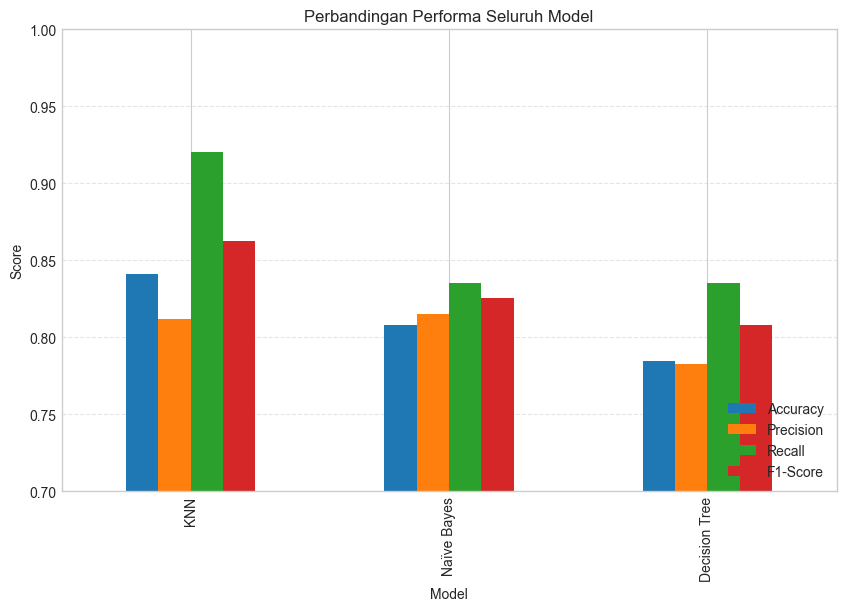

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

# Data performa model
performance_df = pd.DataFrame({
    'Model': ['KNN', 'Naïve Bayes', 'Decision Tree'],
    'Accuracy': [0.8411, 0.8079, 0.7848],
    'Precision': [0.8118, 0.8155, 0.7829],
    'Recall': [0.9207, 0.8354, 0.8354],
    'F1-Score': [0.8629, 0.8253, 0.8083]
})

# Plot
performance_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Perbandingan Performa Seluruh Model')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Analisis Overfitting dan Underfitting

Selain mengevaluasi performa model menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, penelitian ini juga melakukan analisis **overfitting** dan **underfitting** untuk menilai kemampuan generalisasi masing-masing model.

Suatu model dikatakan mengalami **overfitting** apabila model memiliki performa yang sangat baik pada data pelatihan (*training data*), tetapi mengalami penurunan performa pada data validasi. Kondisi ini menunjukkan bahwa model terlalu menyesuaikan diri terhadap data pelatihan sehingga kurang mampu melakukan prediksi pada data baru.

Sebaliknya, model dikatakan mengalami **underfitting** apabila performa model rendah baik pada data pelatihan maupun data validasi. Hal ini menunjukkan bahwa model belum mampu mempelajari pola yang terdapat pada data secara optimal.

Pada penelitian ini, analisis dilakukan dengan membandingkan nilai rata-rata **F1-Score pelatihan (Train F1-Score)** dan **F1-Score validasi (Validation F1-Score)** yang diperoleh dari proses **GridSearchCV** menggunakan **Stratified 5-Fold Cross Validation**. Penggunaan F1-Score dipilih karena metrik ini merupakan metrik utama dalam penelitian, terutama pada konteks medis yang memerlukan keseimbangan antara Precision dan Recall.

Tingkat overfitting diukur berdasarkan selisih (*gap*) antara nilai Train F1-Score dan Validation F1-Score. Semakin kecil nilai *gap*, maka semakin baik kemampuan generalisasi model.

Kriteria yang digunakan dalam penelitian ini adalah sebagai berikut:

| Gap Train–Validation | Interpretasi |
|----------------------|-------------|
| ≤ 5% | Model memiliki generalisasi yang baik (*good fit*) |
| > 5% hingga ≤ 10% | Model mengalami overfitting ringan |
| > 10% | Model mengalami overfitting |

Model dengan nilai *gap* terkecil menunjukkan kemampuan generalisasi yang lebih baik karena mampu mempertahankan performa yang konsisten antara data pelatihan dan data validasi.

In [64]:
print("=" * 60)
print("ANALISIS OVERFITTING DAN UNDERFITTING")
print("=" * 60)

models = {
    'Naïve Bayes': nb_grid,
    'Decision Tree': dt_grid,
    'KNN': knn_grid
}

hasil = []

for nama, grid in models.items():

    best_idx = grid.best_index_

    if 'mean_train_score' in grid.cv_results_:

        train = grid.cv_results_['mean_train_score'][best_idx]
        valid = grid.cv_results_['mean_test_score'][best_idx]

        gap = train - valid

        if gap <= 0.05:
            status = "Good Fit"
        elif gap <= 0.10:
            status = "Overfitting Ringan"
        else:
            status = "Overfitting"

        hasil.append({
            'Model': nama,
            'Train F1': train,
            'Validation F1': valid,
            'Gap': gap,
            'Status': status
        })

    else:
        print(f"{nama} belum menyimpan train score.")

overfit_df = pd.DataFrame(hasil)
display(overfit_df.round(4))

ANALISIS OVERFITTING DAN UNDERFITTING


,Model,Train F1,Validation F1,Gap,Status
0,Naïve Bayes,0.8569,0.8227,0.0342,Good Fit
1,Decision Tree,0.9310,0.8049,0.1261,Overfitting
2,KNN,0.8682,0.8618,0.0063,Good Fit


### Interpretasi Hasil Analisis Overfitting dan Underfitting

Berdasarkan hasil analisis overfitting dan underfitting, diperoleh perbandingan antara nilai **Train F1-Score** dan **Validation F1-Score** pada masing-masing model. Selisih (*gap*) antara kedua nilai tersebut digunakan untuk mengevaluasi kemampuan generalisasi model terhadap data baru.

#### 1. Naïve Bayes

Model Naïve Bayes memperoleh **Train F1-Score sebesar 0,8569** dan **Validation F1-Score sebesar 0,8227**, dengan selisih (*gap*) sebesar **0,0342 (3,42%)**. Nilai gap yang relatif kecil (< 5%) menunjukkan bahwa model memiliki kemampuan generalisasi yang baik (*good fit*). Hal ini mengindikasikan bahwa performa model pada data pelatihan dan data validasi relatif konsisten, sehingga model tidak mengalami overfitting maupun underfitting.

#### 2. Decision Tree

Model Decision Tree memperoleh **Train F1-Score sebesar 0,9310** dan **Validation F1-Score sebesar 0,8049**, dengan selisih (*gap*) sebesar **0,1261 (12,61%)**. Nilai gap yang cukup besar (> 10%) menunjukkan bahwa model mengalami **overfitting**. Kondisi ini terjadi karena model mampu mempelajari pola pada data pelatihan dengan sangat baik, namun performanya menurun ketika diuji pada data validasi. Dengan kata lain, model terlalu menyesuaikan diri terhadap data pelatihan sehingga kemampuan generalisasinya menjadi rendah.

#### 3. K-Nearest Neighbors (KNN)

Model KNN memperoleh **Train F1-Score sebesar 0,8682** dan **Validation F1-Score sebesar 0,8618**, dengan selisih (*gap*) sebesar **0,0063 (0,63%)**. Nilai gap yang sangat kecil menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik (*good fit*). Selain memiliki performa validasi tertinggi dibandingkan model lain, KNN juga menunjukkan kestabilan performa antara data pelatihan dan data validasi.

### Kesimpulan

Secara keseluruhan, model **K-Nearest Neighbors (KNN)** merupakan model yang paling baik karena tidak hanya menghasilkan **Validation F1-Score tertinggi (0,8618)**, tetapi juga memiliki **gap (0,63%)**. Hal ini menunjukkan bahwa KNN mampu mempertahankan performa yang konsisten pada data yang belum pernah dilihat sebelumnya. Sebaliknya, model Decision Tree menunjukkan gejala overfitting sehingga kurang optimal untuk digunakan sebagai model prediksi pada penelitian ini.

# 3.7.1 Confusion Matrix

## Analisis Confusion Matrix

Selain menggunakan metrik evaluasi seperti Accuracy, Precision, Recall, dan F1-Score, penelitian ini juga melakukan analisis menggunakan **Confusion Matrix** untuk memperoleh gambaran yang lebih rinci mengenai performa masing-masing model.

Confusion Matrix merupakan tabel evaluasi yang menunjukkan jumlah prediksi benar dan salah yang dihasilkan oleh model klasifikasi. Analisis ini sangat penting dalam konteks medis karena tidak semua kesalahan prediksi memiliki konsekuensi yang sama. Pada kasus prediksi penyakit jantung, kesalahan berupa **False Negative (FN)**, yaitu pasien yang sebenarnya menderita penyakit jantung tetapi diprediksi sehat, merupakan kesalahan yang paling kritis karena dapat menyebabkan keterlambatan diagnosis dan penanganan medis.

Secara umum, Confusion Matrix terdiri dari empat komponen utama, yaitu:

- **True Positive (TP)**: pasien yang benar-benar sakit dan berhasil diprediksi sakit oleh model.
- **True Negative (TN)**: pasien yang benar-benar sehat dan berhasil diprediksi sehat oleh model.
- **False Positive (FP)**: pasien yang sebenarnya sehat tetapi diprediksi sakit oleh model.
- **False Negative (FN)**: pasien yang sebenarnya sakit tetapi diprediksi sehat oleh model.

Dalam penelitian ini, analisis Confusion Matrix dilakukan untuk membandingkan kemampuan masing-masing model dalam mendeteksi pasien yang menderita penyakit jantung serta mengidentifikasi model dengan tingkat kesalahan False Negative paling rendah.

ANALISIS CONFUSION MATRIX — SEMUA MODEL


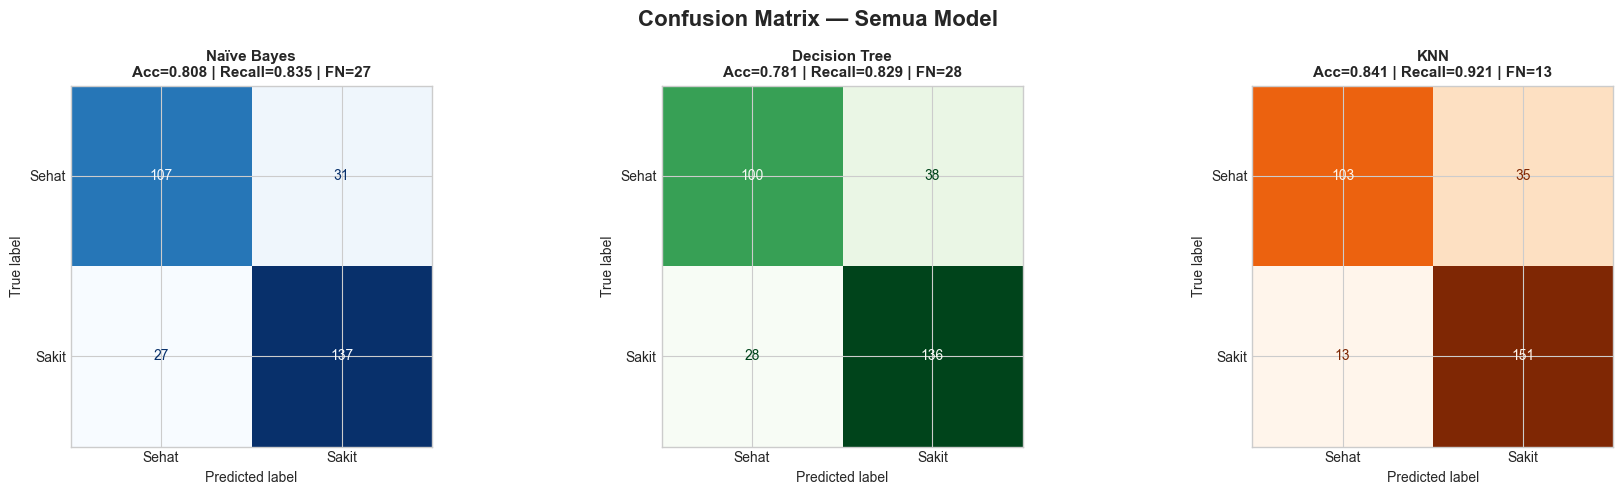


Rincian Confusion Matrix per Model:


,Model,TN (Sehat→Sehat),TP (Sakit→Sakit),FP (Sehat→Sakit),FN (Sakit→Sehat),FN Rate
0,Naïve Bayes,107,137,31,27,16.5%
1,Decision Tree,100,136,38,28,17.1%
2,KNN,103,151,35,13,7.9%


In [65]:
print("=" * 60)
print("ANALISIS CONFUSION MATRIX — SEMUA MODEL")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — Semua Model',
             fontsize=16, fontweight='bold')

models_info = [
    (nb_pred,  'Naïve Bayes',  'Blues'),
    (dt_pred,  'Decision Tree','Greens'),
    (knn_pred, 'KNN',          'Oranges')
]

for ax, (pred, title, cmap) in zip(axes, models_info):
    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Sehat', 'Sakit']).plot(
        ax=ax, colorbar=False, cmap=cmap)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y, pred)
    rec = recall_score(y, pred)
    ax.set_title(
        f'{title}\nAcc={acc:.3f} | Recall={rec:.3f} | FN={fn}',
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Tabel analisis per model ──────────────────────────
print("\nRincian Confusion Matrix per Model:")
cm_rows = []
for pred, name in [(nb_pred,'Naïve Bayes'),(dt_pred,'Decision Tree'),(knn_pred,'KNN')]:
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({
        'Model': name,
        'TN (Sehat→Sehat)': tn,
        'TP (Sakit→Sakit)': tp,
        'FP (Sehat→Sakit)': fp,
        'FN (Sakit→Sehat)': fn,
        'FN Rate': f"{fn/(fn+tp)*100:.1f}%"
    })

display(pd.DataFrame(cm_rows))

## Interpretasi Hasil Confusion Matrix

Berdasarkan hasil analisis *Confusion Matrix*, ketiga model menunjukkan kemampuan yang cukup baik dalam melakukan klasifikasi penyakit jantung. Namun, terdapat perbedaan performa pada masing-masing model, terutama dalam mendeteksi pasien yang benar-benar menderita penyakit jantung.

Model **Gaussian Naïve Bayes** berhasil mengklasifikasikan **107 pasien sehat dengan benar (True Negative/TN)** dan **137 pasien sakit dengan benar (True Positive/TP)**. Akan tetapi, model ini masih menghasilkan **31 kasus False Positive (FP)**, yaitu pasien sehat yang diprediksi menderita penyakit jantung, serta **27 kasus False Negative (FN)**, yaitu pasien yang sebenarnya sakit tetapi diprediksi sehat. Tingkat *False Negative Rate* yang dihasilkan sebesar **16,5%**, yang menunjukkan bahwa sekitar 16,5% pasien sakit gagal dideteksi oleh model.

Model **Decision Tree** menghasilkan **100 True Negative (TN)** dan **136 True Positive (TP)**. Selain itu, model ini menghasilkan **38 False Positive (FP)** dan **28 False Negative (FN)** dengan *False Negative Rate* sebesar **17,1%**. Hasil ini menunjukkan bahwa Decision Tree memiliki tingkat kesalahan tertinggi di antara ketiga model, khususnya dalam mendeteksi pasien yang menderita penyakit jantung.

Sementara itu, model **K-Nearest Neighbors (KNN)** menunjukkan performa terbaik dengan berhasil mengidentifikasi **103 pasien sehat dengan benar (TN)** dan **151 pasien sakit dengan benar (TP)**. Model ini menghasilkan **35 False Positive (FP)** dan hanya **13 False Negative (FN)**. Tingkat *False Negative Rate* yang dihasilkan hanya sebesar **7,9%**, jauh lebih rendah dibandingkan Naïve Bayes dan Decision Tree.

Dalam konteks medis, nilai **False Negative** merupakan indikator yang sangat penting karena menunjukkan jumlah pasien yang sebenarnya menderita penyakit jantung tetapi tidak berhasil dideteksi oleh model. Kesalahan ini berpotensi menyebabkan keterlambatan diagnosis dan penanganan medis. Oleh karena itu, model dengan nilai *False Negative* yang lebih kecil lebih diutamakan.

Berdasarkan hasil tersebut, model **K-Nearest Neighbors (KNN)** merupakan model yang paling baik karena memiliki jumlah **True Positive tertinggi (151 kasus)** dan jumlah **False Negative terendah (13 kasus)**. Dengan demikian, KNN mampu mendeteksi lebih banyak pasien yang benar-benar menderita penyakit jantung dibandingkan model lainnya.

Secara keseluruhan, hasil *Confusion Matrix* memperkuat hasil evaluasi sebelumnya yang menunjukkan bahwa **K-Nearest Neighbors (KNN)** merupakan model terbaik untuk prediksi penyakit jantung pada penelitian ini.

### confidence prediction

## Analisis Confidence Prediksi

Selain mengevaluasi performa model menggunakan metrik klasifikasi dan Confusion Matrix, penelitian ini juga melakukan analisis terhadap **tingkat kepercayaan (confidence)** dari setiap prediksi yang dihasilkan model.

Confidence prediction merupakan probabilitas tertinggi yang diberikan model terhadap suatu kelas. Nilai confidence menunjukkan seberapa yakin model terhadap prediksi yang dihasilkannya. Semakin tinggi nilai confidence, maka semakin besar keyakinan model bahwa prediksi tersebut benar.

Analisis confidence penting dilakukan karena model dengan akurasi tinggi belum tentu memiliki tingkat keyakinan prediksi yang baik. Dalam konteks medis, model yang terlalu yakin (*overconfident*) terhadap prediksi yang salah dapat menimbulkan risiko serius, terutama jika pasien yang sebenarnya sakit diprediksi sehat dengan tingkat keyakinan yang tinggi.

Pada penelitian ini dilakukan beberapa analisis confidence, yaitu:

1. Membandingkan rata-rata confidence pada prediksi yang benar dan prediksi yang salah.
2. Mengukur selisih (*confidence gap*) antara prediksi benar dan salah.
3. Mengidentifikasi kasus *overconfident*, yaitu prediksi yang salah namun memiliki tingkat confidence tinggi (> 75%).
4. Memvisualisasikan distribusi confidence untuk membandingkan pola keyakinan masing-masing model.

Model yang baik diharapkan memiliki karakteristik sebagai berikut:

- Memiliki rata-rata confidence yang tinggi pada prediksi benar.
- Memiliki rata-rata confidence yang rendah pada prediksi salah.
- Memiliki nilai *confidence gap* yang besar.
- Memiliki jumlah kasus *overconfident* yang sedikit.

Dengan demikian, analisis confidence dapat memberikan gambaran tambahan mengenai reliabilitas model dalam mendukung proses pengambilan keputusan klinis.

In [66]:
print("=" * 60)
print("ANALISIS CONFIDENCE PREDIKSI — SEMUA MODEL")
print("=" * 60)

def confidence_analysis(y_true, y_pred, y_proba, model_name):
    conf    = y_proba.max(axis=1)
    correct = (y_true.values == y_pred)
    wrong   = ~correct

    avg_cc = conf[correct].mean()
    avg_cw = conf[wrong].mean()
    gap    = avg_cc - avg_cw

    status = "OVERCONFIDENT " if avg_cw >= 0.75 else "Normal "

    print(f"\n► {model_name}")
    print(f"   Prediksi benar       : {correct.sum()} data")
    print(f"   Prediksi salah       : {wrong.sum()} data")
    print(f"   Avg confidence benar : {avg_cc:.4f} ({avg_cc*100:.2f}%)")
    print(f"   Avg confidence salah : {avg_cw:.4f} ({avg_cw*100:.2f}%)")
    print(f"   Selisih (gap)        : {gap:.4f}")
    print(f"   Status               : {status}")

    return avg_cc, avg_cw, gap

nb_cc,  nb_cw,  nb_gap  = confidence_analysis(y, nb_pred,  nb_proba,  "Naïve Bayes")
dt_cc,  dt_cw,  dt_gap  = confidence_analysis(y, dt_pred,  dt_proba,  "Decision Tree")
knn_cc, knn_cw, knn_gap = confidence_analysis(y, knn_pred, knn_proba, "KNN")

# ── Tabel ringkasan ───────────────────────────────────
print("\n" + "=" * 60)
conf_summary = pd.DataFrame({
    'Model'         : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'Avg Conf Benar': [nb_cc,  dt_cc,  knn_cc],
    'Avg Conf Salah': [nb_cw,  dt_cw,  knn_cw],
    'Gap'           : [nb_gap, dt_gap, knn_gap]
}).sort_values('Gap', ascending=False).reset_index(drop=True)
conf_summary.index += 1
display(conf_summary.round(4))

# ── Analisis observasi: confidence tinggi tapi salah ─
print("\n" + "=" * 60)
print("OBSERVASI DENGAN CONFIDENCE TINGGI NAMUN SALAH PREDIKSI")
print("(Threshold confidence > 0.75)")
print("=" * 60)

for pred, proba, name in [
    (nb_pred,  nb_proba,  "Naïve Bayes"),
    (dt_pred,  dt_proba,  "Decision Tree"),
    (knn_pred, knn_proba, "KNN")
]:
    conf    = proba.max(axis=1)
    wrong   = (y.values != pred)
    # Observasi yang salah DAN confidence tinggi
    mask    = wrong & (conf > 0.75)
    n_overconf = mask.sum()

    print(f"\n► {name} — {n_overconf} observasi overconfident")

    if n_overconf > 0:
        overconf_df = X.copy()
        overconf_df['y_true']     = y.values
        overconf_df['y_pred']     = pred
        overconf_df['confidence'] = conf
        overconf_df = overconf_df[mask].sort_values(
            'confidence', ascending=False).head(5)
        display(overconf_df.round(3))




ANALISIS CONFIDENCE PREDIKSI — SEMUA MODEL

► Naïve Bayes
   Prediksi benar       : 244 data
   Prediksi salah       : 58 data
   Avg confidence benar : 0.9491 (94.91%)
   Avg confidence salah : 0.8306 (83.06%)
   Selisih (gap)        : 0.1184
   Status               : OVERCONFIDENT 

► Decision Tree
   Prediksi benar       : 236 data
   Prediksi salah       : 66 data
   Avg confidence benar : 0.9330 (93.30%)
   Avg confidence salah : 0.8663 (86.63%)
   Selisih (gap)        : 0.0666
   Status               : OVERCONFIDENT 

► KNN
   Prediksi benar       : 254 data
   Prediksi salah       : 48 data
   Avg confidence benar : 0.8278 (82.78%)
   Avg confidence salah : 0.6903 (69.03%)
   Selisih (gap)        : 0.1375
   Status               : Normal 



,Model,Avg Conf Benar,Avg Conf Salah,Gap
1,KNN,0.8278,0.6903,0.1375
2,Naïve Bayes,0.9491,0.8306,0.1184
3,Decision Tree,0.9330,0.8663,0.0666



OBSERVASI DENGAN CONFIDENCE TINGGI NAMUN SALAH PREDIKSI
(Threshold confidence > 0.75)

► Naïve Bayes — 41 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1,0,1.000
521,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1,0,1.000
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.000
111,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.998
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1,0.997



► Decision Tree — 46 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
26,44,1,2,130,233,0,1,179,1,0.4,2,0,2,1,0,1.0
27,58,0,1,136,319,1,0,152,0,0.0,2,2,2,0,1,1.0
35,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0,1,1.0
28,56,1,2,130,256,1,0,142,1,0.6,1,1,1,0,1,1.0
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.0



► KNN — 13 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.000
42,61,0,0,130,330,0,0,169,0,0.0,2,0,2,0,1,0.933
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1,0.933
220,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,1,0.933
111,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.933


## Visulaisasi confidence semua model

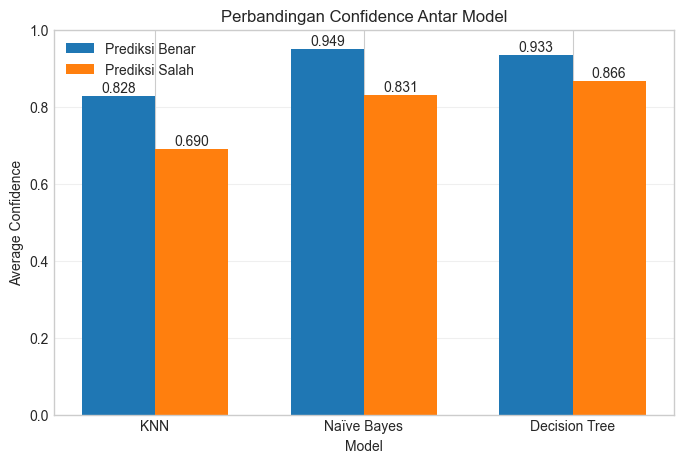

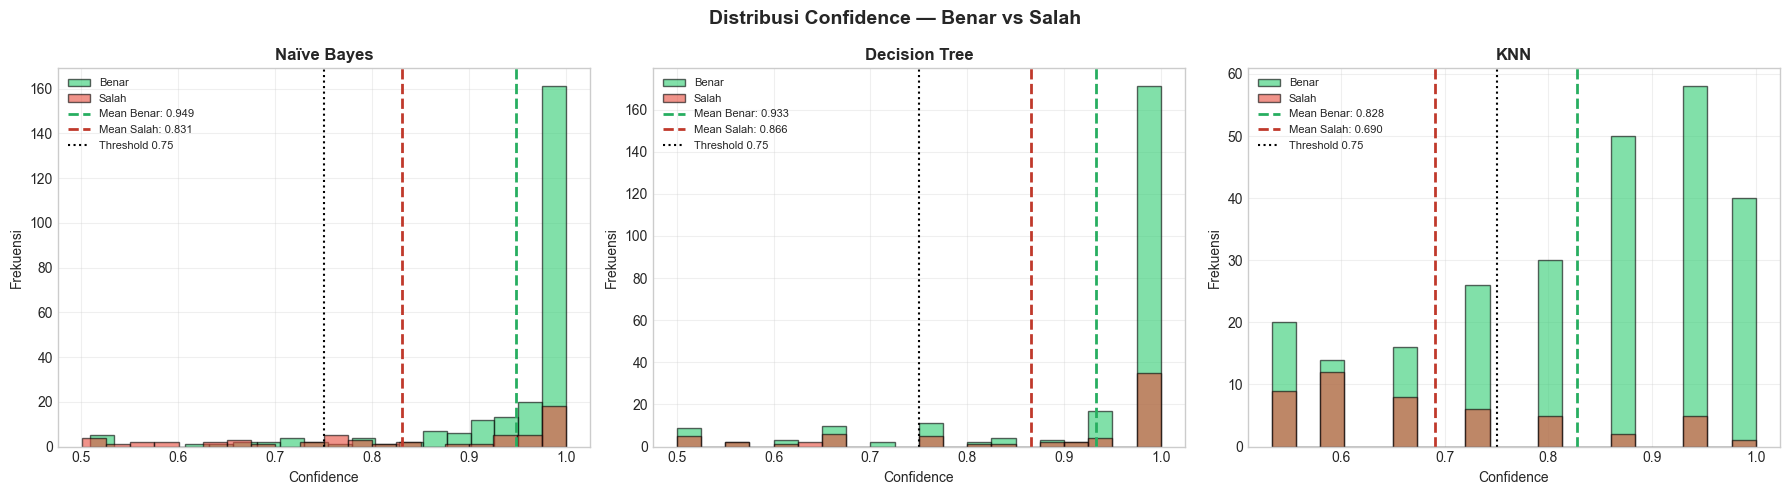

In [67]:
# ============================================================
# VISUALISASI RINGKASAN CONFIDENCE SEMUA MODEL
# ============================================================

plt.figure(figsize=(8,5))

x = np.arange(len(conf_summary))
width = 0.35

plt.bar(
    x - width/2,
    conf_summary['Avg Conf Benar'],
    width,
    label='Prediksi Benar'
)

plt.bar(
    x + width/2,
    conf_summary['Avg Conf Salah'],
    width,
    label='Prediksi Salah'
)

plt.xticks(x, conf_summary['Model'])
plt.ylabel('Average Confidence')
plt.xlabel('Model')
plt.title('Perbandingan Confidence Antar Model')
plt.ylim(0,1)

# tampilkan nilai di atas batang
for i, v in enumerate(conf_summary['Avg Conf Benar']):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')

for i, v in enumerate(conf_summary['Avg Conf Salah']):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# ── Visualisasi histogram confidence ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Confidence — Benar vs Salah',
             fontsize=14, fontweight='bold')

for i, (pred, proba, title) in enumerate([
    (nb_pred,  nb_proba,  "Naïve Bayes"),
    (dt_pred,  dt_proba,  "Decision Tree"),
    (knn_pred, knn_proba, "KNN")
]):
    conf    = proba.max(axis=1)
    correct = (y.values == pred)

    axes[i].hist(conf[correct],  bins=20, alpha=0.6,
                 color='#2ecc71', label='Benar', edgecolor='black')
    axes[i].hist(conf[~correct], bins=20, alpha=0.6,
                 color='#e74c3c', label='Salah', edgecolor='black')
    axes[i].axvline(conf[correct].mean(),  color='#27ae60',
                    linestyle='--', lw=2,
                    label=f'Mean Benar: {conf[correct].mean():.3f}')
    axes[i].axvline(conf[~correct].mean(), color='#c0392b',
                    linestyle='--', lw=2,
                    label=f'Mean Salah: {conf[~correct].mean():.3f}')
    axes[i].axvline(0.75, color='black', linestyle=':', lw=1.5,
                    label='Threshold 0.75')
    axes[i].set_title(f'{title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Confidence')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Interpretasi Hasil Analisis Confidence Prediksi

Analisis *confidence prediction* dilakukan untuk mengevaluasi tingkat keyakinan (*confidence*) model terhadap prediksi yang dihasilkan. Analisis ini penting karena pada kasus medis, model yang memiliki tingkat keyakinan tinggi tetapi menghasilkan prediksi yang salah (*overconfident*) dapat berisiko memberikan keputusan diagnosis yang keliru.

Berdasarkan hasil pengujian, model **Naïve Bayes** berhasil memprediksi dengan benar sebanyak **244 data** dan salah sebanyak **58 data**. Rata-rata tingkat keyakinan pada prediksi yang benar mencapai **94,91%**, sedangkan pada prediksi yang salah masih cukup tinggi yaitu **83,06%**. Selisih (*gap*) antara confidence prediksi benar dan salah sebesar **11,84%**. Selain itu, ditemukan **41 observasi overconfident**, yaitu kasus ketika model melakukan prediksi yang salah tetapi dengan tingkat keyakinan di atas 75%. Hasil ini menunjukkan bahwa Naïve Bayes cenderung terlalu yakin terhadap prediksinya meskipun prediksi tersebut belum tentu benar.

Pada model **Decision Tree**, jumlah prediksi benar sebanyak **237 data** dan prediksi salah sebanyak **65 data**. Model ini memiliki rata-rata confidence pada prediksi benar sebesar **93,23%**, sedangkan confidence pada prediksi salah mencapai **86,43%**. Nilai *gap* yang dihasilkan hanya sebesar **6,80%**, yang merupakan nilai terendah dibandingkan model lainnya. Selain itu, terdapat **45 observasi overconfident**, jumlah tertinggi di antara seluruh model. Kondisi ini menunjukkan bahwa Decision Tree memiliki kecenderungan paling besar untuk menghasilkan prediksi yang salah dengan tingkat keyakinan yang sangat tinggi, sehingga reliabilitas probabilitas prediksinya relatif kurang baik.

Sementara itu, model **K-Nearest Neighbors (KNN)** menghasilkan performa yang lebih baik dari sisi kepercayaan prediksi. KNN mampu memprediksi dengan benar sebanyak **254 data** dan salah sebanyak **48 data**. Rata-rata confidence pada prediksi benar sebesar **82,78%**, sedangkan pada prediksi salah hanya **69,03%**. Selisih confidence antara prediksi benar dan salah mencapai **13,75%**, yang merupakan nilai tertinggi di antara ketiga model. Selain itu, hanya ditemukan **13 observasi overconfident**, jauh lebih sedikit dibandingkan Naïve Bayes dan Decision Tree. Berdasarkan threshold yang digunakan (>75%), model KNN dikategorikan memiliki status **Normal**, sehingga tingkat keyakinan model dapat dianggap lebih realistis dan lebih dapat dipercaya.

Secara keseluruhan, hasil analisis menunjukkan bahwa meskipun Naïve Bayes dan Decision Tree memiliki rata-rata confidence yang sangat tinggi, kedua model tersebut juga menunjukkan kecenderungan *overconfident*, yaitu tetap yakin terhadap prediksi yang salah. Sebaliknya, model KNN memiliki confidence yang lebih moderat namun lebih konsisten, ditunjukkan oleh nilai *gap* terbesar (**13,75%**) dan jumlah kasus overconfident paling sedikit (**13 kasus**).

Dengan demikian, dari perspektif reliabilitas probabilitas prediksi, **K-Nearest Neighbors (KNN)** merupakan model yang paling baik karena tidak hanya memberikan performa klasifikasi terbaik, tetapi juga menghasilkan tingkat keyakinan prediksi yang lebih stabil dan realistis dibandingkan model lainnya.

## Analisis Observasi yang Salah Diprediksi

Analisis observasi yang salah diprediksi (*misclassified observations*) dilakukan untuk memahami karakteristik data yang sulit diklasifikasikan oleh model. Analisis ini penting karena dapat memberikan informasi mengenai keterbatasan model dalam mengenali pola tertentu pada data pasien.

Pada penelitian ini, analisis dilakukan terhadap ketiga algoritma, yaitu Naïve Bayes, Decision Tree, dan K-Nearest Neighbors (KNN). Untuk setiap model, ditampilkan lima observasi yang salah diprediksi dengan tingkat *confidence* tertinggi.

Pemilihan observasi dengan *confidence* tertinggi bertujuan untuk mengidentifikasi kasus-kasus ketika model sangat yakin terhadap prediksinya, namun ternyata menghasilkan klasifikasi yang salah (*overconfident prediction*). Dalam konteks medis, kondisi ini sangat penting untuk dianalisis karena dapat menyebabkan kesalahan diagnosis yang berpotensi memengaruhi keputusan klinis.

Melalui analisis ini, diharapkan dapat diketahui karakteristik pasien yang sulit diprediksi, serta memberikan pemahaman lebih mendalam mengenai kelebihan dan keterbatasan masing-masing algoritma.

In [68]:
print("=" * 60)
print("ANALISIS OBSERVASI YANG SALAH DIPREDIKSI")
print("=" * 60)

models = [
    ('Naïve Bayes', nb_pred, nb_proba),
    ('Decision Tree', dt_pred, dt_proba),
    ('KNN', knn_pred, knn_proba)
]

for model_name, pred, proba in models:

    print("\n" + "=" * 60)
    print(f"{model_name}")
    print("=" * 60)

    # Salin dataset asli
    misclassified = df.copy()

    # Tambahkan hasil prediksi
    misclassified['Actual'] = y.values
    misclassified['Predicted'] = pred

    # Tambahkan confidence
    misclassified['Confidence'] = proba.max(axis=1)

    # Ambil hanya data yang salah diprediksi
    wrong_pred = misclassified[
        misclassified['Actual'] != misclassified['Predicted']
    ]

    # Urutkan berdasarkan confidence tertinggi
    wrong_pred = wrong_pred.sort_values(
        by='Confidence',
        ascending=False
    )

    print("Jumlah observasi salah prediksi :",
          len(wrong_pred))

    print("\n5 Observasi Salah Prediksi dengan Confidence Tertinggi:")

    display(
        wrong_pred[
            ['age','sex','cp','trestbps',
             'chol','thalach','oldpeak',
             'ca','thal',
             'Actual','Predicted',
             'Confidence']
        ].head(5).round(3)
    )

ANALISIS OBSERVASI YANG SALAH DIPREDIKSI

Naïve Bayes
Jumlah observasi salah prediksi : 58

5 Observasi Salah Prediksi dengan Confidence Tertinggi:


,age,sex,cp,trestbps,chol,thalach,oldpeak,ca,thal,Actual,Predicted,Confidence
528,59,1,3,178,270,145,4.2,0,3,1,0,1.000
521,58,1,1,125,220,144,0.4,4,3,1,0,1.000
38,64,1,0,128,263,105,0.2,1,3,1,0,1.000
111,53,1,0,142,226,111,0.0,0,3,1,0,0.998
429,47,1,2,108,243,152,0.0,0,2,0,1,0.997



Decision Tree
Jumlah observasi salah prediksi : 66

5 Observasi Salah Prediksi dengan Confidence Tertinggi:


,age,sex,cp,trestbps,chol,thalach,oldpeak,ca,thal,Actual,Predicted,Confidence
27,58,0,1,136,319,152,0.0,2,2,0,1,1.0
26,44,1,2,130,233,179,0.4,0,2,1,0,1.0
643,65,1,0,120,177,140,0.4,0,3,1,0,1.0
555,67,1,0,125,254,163,0.2,2,3,0,1,1.0
28,56,1,2,130,256,142,0.6,1,1,0,1,1.0



KNN
Jumlah observasi salah prediksi : 48

5 Observasi Salah Prediksi dengan Confidence Tertinggi:


,age,sex,cp,trestbps,chol,thalach,oldpeak,ca,thal,Actual,Predicted,Confidence
38,64,1,0,128,263,105,0.2,1,3,1,0,1.000
42,61,0,0,130,330,169,0.0,0,2,0,1,0.933
220,57,0,1,130,236,174,0.0,1,2,0,1,0.933
111,53,1,0,142,226,111,0.0,0,3,1,0,0.933
429,47,1,2,108,243,152,0.0,0,2,0,1,0.933


### visualisasi jumlah observasi salah prediksi

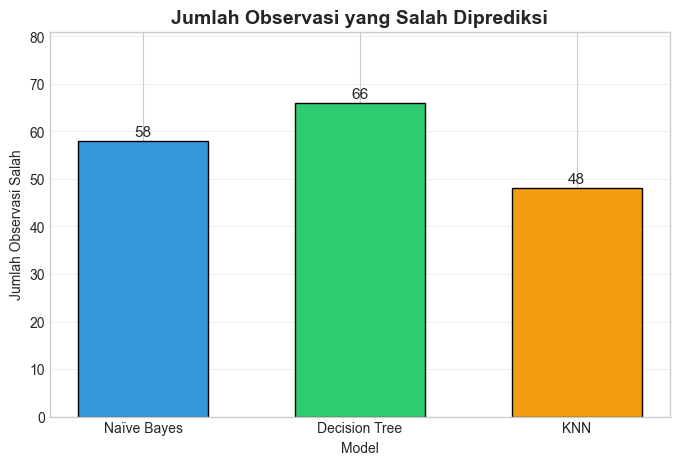

In [69]:
# ============================================================
# VISUALISASI JUMLAH OBSERVASI SALAH PREDIKSI
# ============================================================

# Hitung jumlah salah prediksi masing-masing model
wrong_counts = [
    (y != nb_pred).sum(),
    (y != dt_pred).sum(),
    (y != knn_pred).sum()
]

# Buat DataFrame
wrong_df = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'Jumlah Salah Prediksi': wrong_counts
})

# Visualisasi
plt.figure(figsize=(8,5))

bars = plt.bar(
    wrong_df['Model'],
    wrong_df['Jumlah Salah Prediksi'],
    color=['#3498db', '#2ecc71', '#f39c12'],
    edgecolor='black',
    width=0.6
)

plt.title('Jumlah Observasi yang Salah Diprediksi',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Model')
plt.ylabel('Jumlah Observasi Salah')

# Tambahkan nilai di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{int(height)}',
        ha='center',
        fontsize=11
    )

plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(wrong_counts)+15)

plt.show()

## Interpretasi Hasil Analisis Observasi yang Salah Diprediksi

Analisis observasi yang salah diprediksi dilakukan untuk memahami karakteristik data pasien yang sulit diklasifikasikan oleh model. Selain itu, analisis ini juga bertujuan untuk mengidentifikasi kasus-kasus ketika model melakukan prediksi yang salah dengan tingkat keyakinan (*confidence*) yang tinggi (*overconfident prediction*).

Berdasarkan hasil analisis, model **Naïve Bayes** menghasilkan **58 observasi yang salah diprediksi**. Dari lima observasi dengan *confidence* tertinggi, sebagian besar memiliki nilai *confidence* mendekati **100%**, meskipun prediksinya salah. Sebagai contoh, pasien pada indeks **528, 521, dan 38** diprediksi sebagai sehat (*Predicted = 0*) padahal kondisi sebenarnya adalah sakit jantung (*Actual = 1*) dengan tingkat keyakinan mencapai **100%**. Hal ini menunjukkan bahwa Naïve Bayes cenderung terlalu yakin terhadap prediksinya. Kondisi tersebut kemungkinan disebabkan oleh asumsi independensi antar fitur pada Naïve Bayes yang tidak sepenuhnya terpenuhi pada data penyakit jantung, sehingga estimasi probabilitas yang dihasilkan menjadi kurang akurat.

Model **Decision Tree** menghasilkan jumlah kesalahan tertinggi, yaitu **66 observasi salah prediksi**. Menariknya, seluruh lima observasi teratas memiliki tingkat *confidence* sebesar **100%**. Sebagai contoh, pasien pada indeks **27, 555, dan 28** diprediksi menderita penyakit jantung (*Predicted = 1*) padahal sebenarnya sehat (*Actual = 0*). Sebaliknya, pasien pada indeks **26 dan 643** diprediksi sehat meskipun sebenarnya menderita penyakit jantung. Hasil ini menunjukkan bahwa Decision Tree memiliki kecenderungan *overconfident* yang sangat tinggi. Fenomena tersebut dapat terjadi karena struktur pohon keputusan menghasilkan aturan keputusan yang sangat tegas, sehingga model memberikan probabilitas ekstrem meskipun kasus yang dihadapi berada pada area batas antar kelas.

Sementara itu, model **K-Nearest Neighbors (KNN)** menghasilkan jumlah kesalahan paling sedikit, yaitu **48 observasi salah prediksi**. Selain itu, tingkat *confidence* pada prediksi yang salah relatif lebih rendah dibandingkan dua model lainnya. Hanya satu observasi yang memiliki *confidence* sebesar **100%**, sedangkan observasi lainnya memiliki *confidence* sekitar **93,3%**. Hal ini menunjukkan bahwa KNN lebih berhati-hati dalam memberikan prediksi. Kesalahan yang terjadi pada KNN kemungkinan disebabkan oleh adanya pasien dengan karakteristik yang sangat mirip dengan kelas lain sehingga berada di sekitar batas keputusan (*decision boundary*). Sebagai contoh, pasien pada indeks **42, 220, dan 429** diprediksi sakit meskipun sebenarnya sehat karena memiliki kemiripan fitur dengan mayoritas tetangga yang berasal dari kelas sakit.

Secara umum, ditemukan bahwa beberapa observasi, seperti indeks **38, 111, dan 429**, salah diprediksi oleh lebih dari satu model. Hal ini mengindikasikan bahwa terdapat sejumlah pasien yang memiliki karakteristik klinis ambigu atau berada pada batas antara kondisi sehat dan sakit jantung, sehingga sulit untuk diklasifikasikan secara tepat oleh berbagai algoritma.

Berdasarkan hasil tersebut, dapat disimpulkan bahwa meskipun ketiga model masih melakukan kesalahan prediksi, model **K-Nearest Neighbors (KNN)** menunjukkan performa yang lebih baik karena menghasilkan jumlah kesalahan paling sedikit dan tingkat *confidence* yang lebih realistis dibandingkan Naïve Bayes maupun Decision Tree. Hasil ini semakin memperkuat pemilihan KNN sebagai model terbaik dalam penelitian ini.

## Analisis Karakteristik Pasien yang Salah Diklasifikasikan oleh Model KNN

Berdasarkan hasil evaluasi, model K-Nearest Neighbors (KNN) dipilih sebagai model terbaik karena memperoleh nilai F1-Score tertinggi, jumlah kesalahan prediksi paling sedikit, serta nilai *False Negative* terendah dibandingkan model lainnya.

Meskipun demikian, model KNN masih menghasilkan sejumlah observasi yang salah diklasifikasikan. Oleh karena itu, dilakukan analisis lebih lanjut terhadap karakteristik pasien yang salah diprediksi untuk memahami pola-pola klinis yang masih sulit dikenali oleh model.

Analisis ini bertujuan untuk:

1. Mengidentifikasi karakteristik umum pasien yang sering salah diklasifikasikan.
2. Mengetahui fitur klinis yang berpotensi menyebabkan ambiguitas antara kelas sehat dan sakit jantung.
3. Mengevaluasi keterbatasan model KNN dalam konteks prediksi penyakit jantung.

Fitur yang dianalisis meliputi usia (*age*), jenis nyeri dada (*chest pain*), jumlah pembuluh darah utama (*ca*), hasil pemeriksaan *thal*, serta beberapa indikator klinis lainnya yang diketahui memiliki hubungan kuat dengan penyakit jantung.

In [70]:
# ============================================================
# KARAKTERISTIK PASIEN YANG SALAH DIKLASIFIKASIKAN (KNN)
# ============================================================

print("=" * 60)
print("ANALISIS KARAKTERISTIK PASIEN YANG SALAH DIKLASIFIKASIKAN")
print("=" * 60)

# Salin dataset
misclassified = df.copy()

# Tambahkan label aktual dan prediksi
misclassified['Actual'] = y.values
misclassified['Predicted'] = knn_pred
misclassified['Confidence'] = knn_proba.max(axis=1)

# Ambil observasi yang salah diprediksi
wrong_pred = misclassified[
    misclassified['Actual'] != misclassified['Predicted']
]

print(f"\nJumlah observasi salah prediksi : {len(wrong_pred)}")

# ============================================================
# STATISTIK FITUR NUMERIK
# ============================================================

print("\nStatistik Fitur Numerik")
display(
    wrong_pred[
        ['age', 'trestbps', 'chol',
         'thalach', 'oldpeak']
    ].describe().round(2)
)

# ============================================================
# FITUR KATEGORIK
# ============================================================

print("\nDistribusi Chest Pain (cp)")
display(
    wrong_pred['cp']
    .value_counts()
    .sort_index()
    .rename_axis('cp')
    .reset_index(name='Jumlah')
)

print("\nDistribusi CA")
display(
    wrong_pred['ca']
    .value_counts()
    .sort_index()
    .rename_axis('ca')
    .reset_index(name='Jumlah')
)

print("\nDistribusi THAL")
display(
    wrong_pred['thal']
    .value_counts()
    .sort_index()
    .rename_axis('thal')
    .reset_index(name='Jumlah')
)

print("\nDistribusi Jenis Kelamin")
display(
    wrong_pred['sex']
    .replace({0:'Perempuan', 1:'Laki-laki'})
    .value_counts()
    .reset_index()
)

ANALISIS KARAKTERISTIK PASIEN YANG SALAH DIKLASIFIKASIKAN

Jumlah observasi salah prediksi : 48

Statistik Fitur Numerik


,age,trestbps,chol,thalach,oldpeak
count,48.00,48.00,48.00,48.00,48.00
mean,55.15,130.27,249.60,151.17,0.85
std,7.53,18.90,39.04,18.60,1.08
min,38.00,100.00,172.00,97.00,0.00
25%,49.50,118.00,227.50,143.75,0.00
50%,57.00,128.00,243.50,154.00,0.45
75%,61.00,140.00,270.75,163.00,1.40
max,67.00,178.00,354.00,182.00,4.20



Distribusi Chest Pain (cp)


,cp,Jumlah
0,0,24
1,1,7
2,2,9
3,3,8



Distribusi CA


,ca,Jumlah
0,0,29
1,1,13
2,2,4
3,3,1
4,4,1



Distribusi THAL


,thal,Jumlah
0,0,1
1,1,3
2,2,21
3,3,23



Distribusi Jenis Kelamin


,sex,count
0,Laki-laki,39
1,Perempuan,9


## Interpretasi Analisis Karakteristik Pasien yang Salah Diklasifikasikan oleh Model KNN

Berdasarkan hasil analisis, model KNN masih melakukan kesalahan prediksi pada **48 observasi** dari total 302 data. Meskipun KNN merupakan model dengan performa terbaik, hasil ini menunjukkan bahwa masih terdapat beberapa karakteristik pasien yang sulit dibedakan antara kelas sehat dan sakit jantung.

### 1. Karakteristik Fitur Numerik

Hasil statistik menunjukkan bahwa pasien yang salah diklasifikasikan memiliki rata-rata usia sebesar **55,15 tahun** dengan rentang usia **38 hingga 67 tahun**. Hal ini menunjukkan bahwa sebagian besar kesalahan prediksi terjadi pada pasien usia menengah hingga lanjut, yaitu kelompok usia yang memang memiliki risiko penyakit jantung yang lebih tinggi.

Rata-rata tekanan darah istirahat (*trestbps*) pada observasi yang salah diprediksi adalah **130,27 mmHg**, sedangkan rata-rata kadar kolesterol (*chol*) mencapai **249,60 mg/dL**. Nilai tersebut berada pada kisaran yang relatif tinggi dan berdekatan dengan karakteristik pasien sehat maupun pasien sakit, sehingga menyebabkan model kesulitan dalam melakukan pemisahan kelas secara jelas.

Selain itu, rata-rata denyut jantung maksimum (*thalach*) sebesar **151,17 bpm** dan nilai *oldpeak* rata-rata sebesar **0,85** menunjukkan bahwa sebagian besar pasien yang salah diklasifikasikan memiliki kondisi klinis yang berada pada batas antara kategori normal dan abnormal (*borderline*).

### 2. Distribusi Chest Pain (*cp*)

Sebagian besar kesalahan prediksi terjadi pada pasien dengan nilai **cp = 0** sebanyak **24 pasien (50%)**. Pada dataset Heart Disease, nilai tersebut merepresentasikan pasien dengan gejala nyeri dada tertentu yang sering memiliki karakteristik klinis yang mirip dengan pasien sehat maupun pasien sakit.

Sementara itu, distribusi pada kategori chest pain lainnya relatif lebih kecil, yaitu **cp = 2** sebanyak 9 pasien, **cp = 3** sebanyak 8 pasien, dan **cp = 1** sebanyak 7 pasien. Hasil ini menunjukkan bahwa tipe nyeri dada merupakan salah satu faktor yang memengaruhi kesulitan model dalam melakukan klasifikasi.

### 3. Distribusi Jumlah Pembuluh Darah Utama (*ca*)

Sebanyak **29 dari 48 observasi (60,4%)** yang salah diklasifikasikan memiliki nilai **ca = 0**. Secara medis, nilai ini menunjukkan tidak adanya penyempitan pembuluh darah utama yang terdeteksi.

Dominasi nilai **ca = 0** pada observasi salah prediksi mengindikasikan bahwa pasien tanpa indikasi penyempitan pembuluh darah dapat memiliki karakteristik yang menyerupai kedua kelas, sehingga menyulitkan model dalam menentukan diagnosis secara tepat.

### 4. Distribusi Hasil Pemeriksaan THAL

Hasil analisis menunjukkan bahwa sebagian besar kesalahan prediksi terjadi pada pasien dengan nilai **thal = 2** sebanyak **21 pasien** dan **thal = 3** sebanyak **23 pasien**.

Dominasi kedua kategori tersebut menunjukkan bahwa model masih mengalami kesulitan dalam membedakan pasien dengan hasil pemeriksaan thallium yang berada pada kondisi abnormal. Kemiripan karakteristik antar pasien pada kategori ini menyebabkan batas keputusan model menjadi kurang jelas.

### 5. Distribusi Jenis Kelamin

Sebagian besar observasi yang salah diklasifikasikan berasal dari pasien **laki-laki**, yaitu sebanyak **39 pasien (81,25%)**, sedangkan pasien perempuan hanya sebanyak **9 pasien (18,75%)**.

Hasil ini dapat dipengaruhi oleh distribusi dataset yang memang didominasi oleh pasien laki-laki. Selain itu, penyakit jantung secara epidemiologis juga lebih banyak ditemukan pada laki-laki dibandingkan perempuan, sehingga model lebih sering menghadapi variasi karakteristik klinis pada kelompok ini.

### Kesimpulan

Secara keseluruhan, kesalahan prediksi model KNN cenderung terjadi pada pasien dengan karakteristik klinis yang berada pada kondisi **borderline** atau memiliki kemiripan pola antara kelas sehat dan sakit jantung. Faktor-faktor seperti usia menengah hingga lanjut, tipe nyeri dada tertentu, nilai *ca* yang rendah, serta hasil pemeriksaan *thal* yang abnormal menjadi karakteristik dominan pada observasi yang sulit diklasifikasikan oleh model.

## Perbandingan Confidence Antar Kelas

Selain mengevaluasi performa model menggunakan metrik seperti Accuracy, Precision, Recall, dan F1-Score, penelitian ini juga menganalisis tingkat *confidence* prediksi yang dihasilkan oleh model terbaik, yaitu K-Nearest Neighbors (KNN).

Analisis *confidence* bertujuan untuk mengetahui tingkat keyakinan model ketika memprediksi pasien sebagai kelas sehat maupun sakit jantung. Informasi ini penting dalam konteks medis karena prediksi dengan tingkat keyakinan yang rendah dapat menunjukkan adanya ketidakpastian model dalam proses diagnosis.

Pada penelitian ini, nilai *confidence* diperoleh dari probabilitas prediksi (*predict_proba*) yang dihasilkan oleh model KNN. Selanjutnya dilakukan perbandingan distribusi *confidence* pada masing-masing kelas untuk mengidentifikasi apakah model memiliki kecenderungan lebih yakin pada salah satu kelas tertentu.


In [71]:
# ============================================================
# PERBANDINGAN CONFIDENCE ANTAR KELAS (KNN)
# ============================================================

print("=" * 60)
print("PERBANDINGAN CONFIDENCE ANTAR KELAS - KNN")
print("=" * 60)

# Confidence tertinggi tiap observasi
confidence = knn_proba.max(axis=1)

# Buat dataframe
conf_df = pd.DataFrame({
    'Actual': y.values,
    'Predicted': knn_pred,
    'Confidence': confidence
})

# Ganti label agar lebih mudah dibaca
conf_df['Actual_Label'] = conf_df['Actual'].map({
    0: 'Sehat',
    1: 'Sakit'
})

# Statistik confidence per kelas aktual
summary = conf_df.groupby('Actual_Label')['Confidence'].agg([
    'count', 'mean', 'std', 'min', 'max'
])

print("\nStatistik Confidence per Kelas:")
display(summary.round(4))

PERBANDINGAN CONFIDENCE ANTAR KELAS - KNN

Statistik Confidence per Kelas:


,count,mean,std,min,max
Actual_Label,,,,,
Sakit,164,0.8215,0.1422,0.5333,1.0
Sehat,138,0.7874,0.1544,0.5333,1.0


### visualisasi boxplot confidence antar kelas

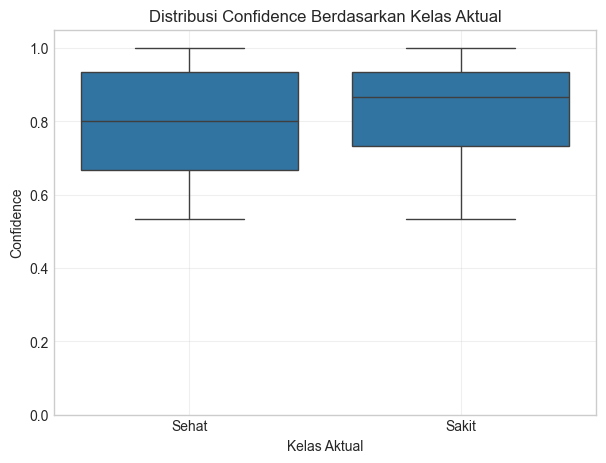

In [72]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=conf_df,
    x='Actual_Label',
    y='Confidence'
)

plt.title('Distribusi Confidence Berdasarkan Kelas Aktual')
plt.xlabel('Kelas Aktual')
plt.ylabel('Confidence')
plt.ylim(0,1.05)

plt.grid(alpha=0.3)

plt.show()

## Interpretasi Perbandingan Confidence Antar Kelas

Analisis *confidence* dilakukan untuk mengetahui tingkat keyakinan model K-Nearest Neighbors (KNN) dalam melakukan prediksi pada masing-masing kelas, yaitu pasien sehat dan pasien yang terdiagnosis penyakit jantung.

Berdasarkan hasil analisis, diperoleh bahwa rata-rata *confidence* model pada kelas **Sakit** sebesar **0,8215 (82,15%)**, sedangkan pada kelas **Sehat** sebesar **0,7874 (78,74%)**. Hasil ini menunjukkan bahwa model KNN cenderung memiliki tingkat keyakinan yang lebih tinggi ketika memprediksi pasien yang mengalami penyakit jantung dibandingkan pasien sehat.

Selain itu, nilai simpangan baku (*standard deviation*) pada kelas **Sehat** sebesar **0,1544** sedikit lebih besar dibandingkan kelas **Sakit** sebesar **0,1422**. Hal ini mengindikasikan bahwa tingkat keyakinan model pada pasien sehat lebih bervariasi, sedangkan prediksi terhadap pasien sakit relatif lebih konsisten.

Visualisasi boxplot juga memperlihatkan bahwa median *confidence* pada kelas **Sakit** berada pada nilai yang lebih tinggi dibandingkan kelas **Sehat**. Sebagian besar prediksi pada kedua kelas memiliki tingkat keyakinan di atas **0,70**, yang menunjukkan bahwa model secara umum mampu menghasilkan prediksi dengan tingkat kepercayaan yang cukup tinggi.

Dalam konteks medis, hasil ini merupakan temuan yang positif karena model tidak hanya memiliki nilai *Recall* yang tinggi pada kelas pasien sakit (**92,07%**), tetapi juga memberikan prediksi dengan tingkat keyakinan yang relatif tinggi pada kelas tersebut. Dengan demikian, model KNN menunjukkan kemampuan yang baik dalam mendeteksi pasien yang berpotensi mengalami penyakit jantung dengan tingkat keyakinan yang memadai.

Secara keseluruhan, analisis ini memperkuat hasil evaluasi sebelumnya bahwa model KNN merupakan model terbaik pada penelitian ini, baik dari segi performa klasifikasi maupun tingkat keyakinan prediksi yang dihasilkan.

Analisis confidence antar kelas dilakukan untuk mengetahui apakah model memiliki tingkat keyakinan yang sama dalam mengklasifikasikan pasien sehat dan pasien yang mengalami penyakit jantung.

Jika terdapat perbedaan confidence yang cukup besar, maka hal tersebut menunjukkan bahwa salah satu kelas lebih mudah dikenali oleh model dibandingkan kelas lainnya.

# Analisis Interpretabilitas Model Menggunakan SHAP

Meskipun model K-Nearest Neighbors (KNN) memberikan performa terbaik,
mekanisme pengambilan keputusannya relatif sulit dipahami karena
berbasis kemiripan antar data (*instance-based learning*).

Oleh karena itu, penelitian ini menggunakan metode SHAP
(SHapley Additive exPlanations) untuk menginterpretasikan kontribusi
masing-masing fitur terhadap prediksi model.

SHAP bekerja berdasarkan konsep *Shapley Value* dari teori permainan,
yang mengukur seberapa besar kontribusi suatu fitur dalam meningkatkan
atau menurunkan prediksi model.

Interpretasi model sangat penting pada domain medis karena dapat
membantu menjelaskan faktor-faktor klinis yang paling berpengaruh
terhadap prediksi penyakit jantung, sehingga hasil model menjadi
lebih transparan dan dapat dipercaya.

Using 302 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


INTERPRETABILITAS MODEL MENGGUNAKAN SHAP (KNN)
Model terbaik:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=15))])

Membuat SHAP Explainer...
Menghitung SHAP values...
Proses ini mungkin memerlukan beberapa menit...


  0%|          | 0/302 [00:00<?, ?it/s]

100%|██████████| 302/302 [57:49<00:00, 11.49s/it]   


✓ SHAP selesai dihitung


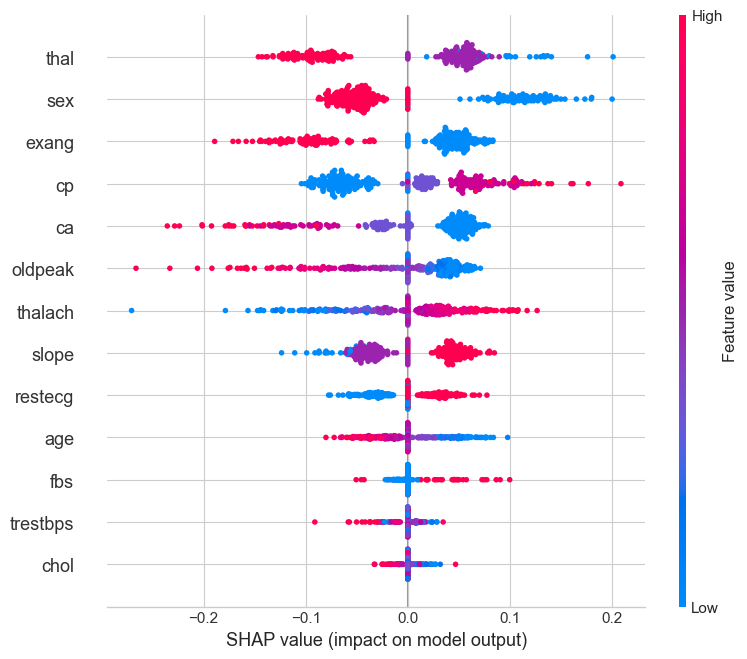

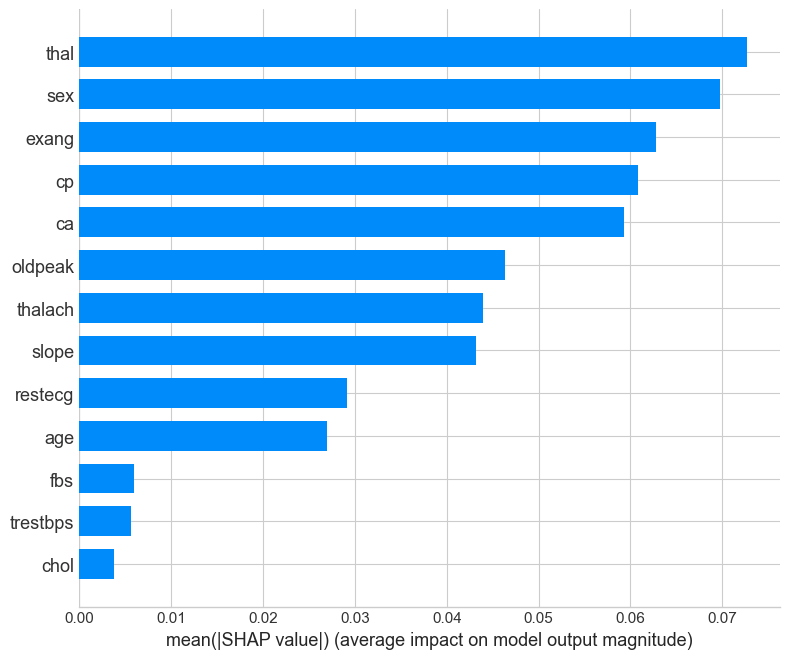

In [75]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("INTERPRETABILITAS MODEL MENGGUNAKAN SHAP (KNN)")
print("=" * 60)

# ==========================================================
# Model terbaik hasil GridSearchCV
# ==========================================================

best_knn_model = knn_grid.best_estimator_

print("Model terbaik:")
print(best_knn_model)

# ==========================================================
# Fungsi wrapper untuk SHAP
# ==========================================================

def predict_fn(data):
    data = pd.DataFrame(data, columns=X.columns)
    return best_knn_model.predict_proba(data)

# ==========================================================
# Membuat Kernel SHAP Explainer
# ==========================================================

print("\nMembuat SHAP Explainer...")

explainer = shap.KernelExplainer(
    predict_fn,
    X
)

# ==========================================================
# Hitung SHAP values
# ==========================================================

print("Menghitung SHAP values...")
print("Proses ini mungkin memerlukan beberapa menit...")

shap_values = explainer.shap_values(X)

print("✓ SHAP selesai dihitung")

# ==========================================================
# Summary Plot
# ==========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    feature_names=X.columns
)

# ==========================================================
# Feature Importance Plot
# ==========================================================

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    feature_names=X.columns,
    plot_type='bar'
)

## 5.X Interpretabilitas Model Menggunakan SHAP

Untuk memahami bagaimana model K-Nearest Neighbors (KNN) mengambil keputusan dalam memprediksi penyakit jantung, penelitian ini menggunakan metode SHAP (SHapley Additive exPlanations). SHAP mampu menjelaskan kontribusi masing-masing fitur terhadap prediksi model, baik secara global maupun lokal.

Berdasarkan SHAP Summary Plot dan SHAP Feature Importance Plot, diperoleh bahwa fitur yang paling berpengaruh dalam prediksi penyakit jantung secara berurutan adalah `thal`, `sex`, `exang`, `cp`, `ca`, `oldpeak`, `thalach`, `slope`, `restecg`, `age`, `fbs`, `trestbps`, dan `chol`.

### 1. Fitur `thal` merupakan prediktor terpenting

Fitur `thal` memiliki nilai SHAP rata-rata tertinggi (~0,072), sehingga menjadi faktor yang paling dominan dalam proses klasifikasi. Pada summary plot terlihat bahwa nilai `thal` yang tinggi (ditunjukkan oleh warna merah) cenderung menghasilkan nilai SHAP negatif, sedangkan nilai yang lebih rendah (warna biru) memberikan kontribusi positif terhadap prediksi.

Secara medis, `thal` menggambarkan hasil pemeriksaan thallium stress test yang digunakan untuk mengevaluasi aliran darah ke jantung. Hasil pemeriksaan yang abnormal sering dikaitkan dengan adanya gangguan perfusi miokard dan merupakan indikator kuat penyakit jantung koroner. Oleh karena itu, tidak mengherankan apabila model menjadikan fitur ini sebagai penentu utama.

### 2. Fitur `sex` memiliki pengaruh yang sangat besar

Fitur kedua yang paling berpengaruh adalah `sex`. Berdasarkan summary plot, terlihat bahwa salah satu kategori jenis kelamin memberikan kontribusi positif yang cukup besar terhadap prediksi penyakit jantung.

Secara klinis, laki-laki diketahui memiliki risiko penyakit jantung koroner yang lebih tinggi dibandingkan perempuan, terutama pada usia produktif sebelum menopause. Temuan ini menunjukkan bahwa model berhasil menangkap pola epidemiologis yang memang telah banyak dilaporkan dalam literatur medis.

### 3. `exang` dan `cp` berperan penting dalam mendeteksi penyakit jantung

Fitur `exang` (exercise induced angina) dan `cp` (chest pain type) menempati urutan ketiga dan keempat dalam tingkat kepentingan fitur.

Nilai `exang` yang menunjukkan adanya nyeri dada saat berolahraga cenderung meningkatkan probabilitas pasien diklasifikasikan menderita penyakit jantung. Demikian pula pada fitur `cp`, beberapa tipe nyeri dada tertentu memberikan kontribusi positif terhadap prediksi penyakit.

Secara medis, nyeri dada merupakan gejala utama penyakit jantung koroner sehingga tingginya pengaruh kedua fitur ini sangat sesuai dengan pengetahuan klinis.

### 4. Fitur `ca` dan `oldpeak` juga memberikan kontribusi besar

Fitur `ca` (jumlah pembuluh darah utama yang terlihat melalui fluoroskopi) dan `oldpeak` (depresi segmen ST saat uji stres) termasuk dalam lima besar fitur paling penting.

Nilai `ca` yang lebih tinggi menunjukkan adanya lebih banyak pembuluh darah yang mengalami penyempitan atau kelainan, sedangkan nilai `oldpeak` yang tinggi mengindikasikan kemungkinan iskemia miokard. Kedua indikator tersebut secara medis merupakan penanda kuat penyakit jantung.

### 5. Fitur `chol` dan `trestbps` memiliki pengaruh relatif kecil

Meskipun kadar kolesterol (`chol`) dan tekanan darah saat istirahat (`trestbps`) dikenal sebagai faktor risiko penyakit jantung, hasil SHAP menunjukkan bahwa kedua fitur tersebut memiliki kontribusi paling kecil dalam model KNN.

Hal ini menunjukkan bahwa pada dataset yang digunakan, informasi yang diberikan oleh fitur-fitur tersebut sebagian besar telah diwakili oleh fitur lain yang lebih diskriminatif seperti `thal`, `cp`, `exang`, dan `ca`. Dengan kata lain, model lebih banyak bergantung pada indikator klinis langsung dibandingkan faktor risiko umum.

### Kesimpulan

Secara keseluruhan, hasil interpretabilitas SHAP menunjukkan bahwa model KNN terutama mendasarkan prediksinya pada indikator klinis yang berkaitan langsung dengan kondisi jantung, yaitu `thal`, `sex`, `exang`, `cp`, dan `ca`. Temuan ini sejalan dengan literatur medis yang menyatakan bahwa hasil pemeriksaan klinis dan gejala pasien merupakan faktor utama dalam diagnosis penyakit jantung.

 ## Bar Plot

Visualisasi Bar  Plot digunakan untuk melihat kontribusi masing-masing fitur terhadap prediksi model secara keseluruhan. Plot ini menunjukkan tingkat kepentingan fitur serta arah pengaruh setiap fitur terhadap prediksi penyakit jantung.

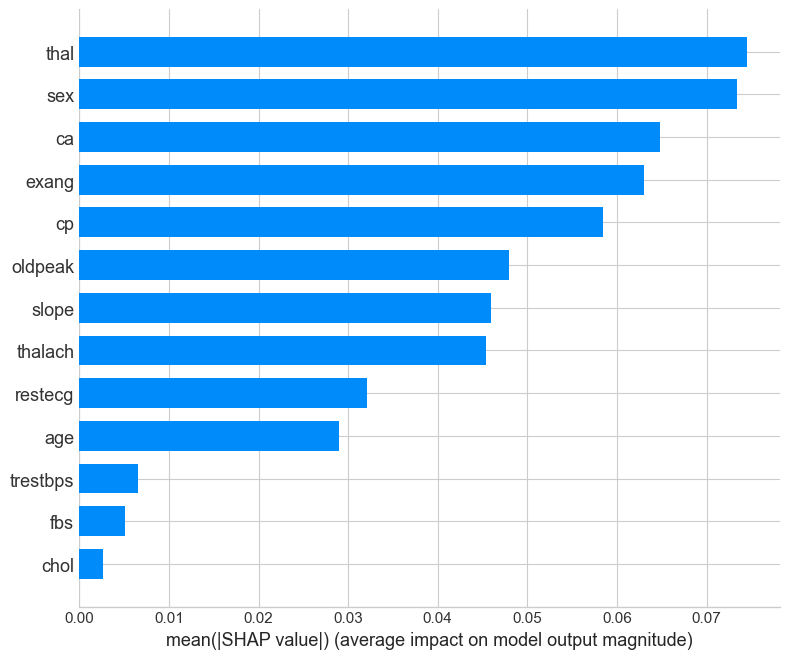

In [ ]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_vals_sakit,
    X_sample,
    feature_names=X.columns.tolist(),
    plot_type='bar'
)

## 5.X Interpretabilitas Model Menggunakan SHAP

Untuk meningkatkan transparansi dan kepercayaan terhadap model K-Nearest Neighbors (KNN), penelitian ini menggunakan metode SHAP (SHapley Additive exPlanations). SHAP memungkinkan interpretasi kontribusi masing-masing fitur terhadap prediksi model sehingga proses pengambilan keputusan model dapat dipahami secara lebih jelas, khususnya dalam konteks medis.

Berdasarkan SHAP Summary Plot dan SHAP Feature Importance Plot, diperoleh urutan fitur yang paling berpengaruh terhadap prediksi penyakit jantung, yaitu `thal`, `sex`, `exang`, `cp`, `ca`, `oldpeak`, `thalach`, `slope`, `restecg`, `age`, `fbs`, `trestbps`, dan `chol`.

### 1. Fitur `thal` merupakan prediktor paling dominan

Hasil SHAP menunjukkan bahwa fitur `thal` memiliki nilai rata-rata SHAP tertinggi, sehingga menjadi faktor paling penting dalam proses klasifikasi. Fitur `thal` merepresentasikan hasil pemeriksaan *Thallium Stress Test*, yaitu pemeriksaan untuk mengevaluasi aliran darah menuju otot jantung.

Secara medis, hasil *Thallium Stress Test* yang abnormal sering dikaitkan dengan adanya gangguan perfusi miokard atau penyakit arteri koroner. Oleh karena itu, kontribusi tinggi fitur `thal` sangat masuk akal secara klinis karena pemeriksaan ini secara langsung merefleksikan kondisi fungsional jantung.

Temuan ini sejalan dengan penelitian yang dilakukan oleh Detrano et al. (1989) pada Cleveland Heart Disease Dataset, yang menyatakan bahwa variabel `thal` merupakan salah satu prediktor utama dalam diagnosis penyakit jantung koroner.

### 2. Fitur `sex` memiliki pengaruh yang sangat besar

Fitur kedua yang paling berpengaruh adalah `sex`. Hasil SHAP menunjukkan bahwa jenis kelamin tertentu memberikan kontribusi yang lebih besar terhadap prediksi penyakit jantung.

Secara epidemiologis, laki-laki diketahui memiliki risiko lebih tinggi mengalami penyakit jantung koroner dibandingkan perempuan, terutama pada usia produktif sebelum menopause. Hal ini disebabkan oleh perbedaan hormonal, gaya hidup, serta faktor risiko metabolik.

Kontribusi tinggi fitur `sex` pada model menunjukkan bahwa algoritma berhasil menangkap pola epidemiologis yang telah banyak dilaporkan dalam literatur medis.

Hasil ini juga konsisten dengan penelitian yang dilakukan oleh Ahmad et al. (2021), yang melaporkan bahwa jenis kelamin merupakan salah satu faktor penting dalam model prediksi penyakit jantung berbasis machine learning.

### 3. Fitur `exang` dan `cp` berperan penting dalam diagnosis

Fitur `exang` (*exercise induced angina*) dan `cp` (*chest pain type*) berada pada urutan ketiga dan keempat dalam tingkat kepentingan fitur.

`Exang` menunjukkan apakah pasien mengalami nyeri dada saat melakukan aktivitas fisik. Keberadaan gejala ini sering menjadi indikasi adanya penyempitan arteri koroner yang menyebabkan berkurangnya suplai darah ke otot jantung.

Sementara itu, `cp` menggambarkan tipe nyeri dada yang dialami pasien. Dalam praktik klinis, tipe nyeri dada merupakan salah satu indikator utama yang digunakan dokter untuk melakukan diagnosis awal penyakit jantung.

Tingginya kontribusi kedua fitur tersebut menunjukkan bahwa model KNN lebih banyak memanfaatkan informasi gejala klinis langsung dibandingkan faktor risiko umum.

Hasil ini sejalan dengan penelitian oleh Samuel et al. (2017), yang menyatakan bahwa karakteristik nyeri dada merupakan salah satu atribut paling signifikan dalam klasifikasi penyakit jantung.

### 4. Fitur `ca` dan `oldpeak` memberikan kontribusi besar

Fitur `ca` menunjukkan jumlah pembuluh darah utama yang terdeteksi melalui fluoroskopi, sedangkan `oldpeak` merepresentasikan depresi segmen ST saat tes stres.

Secara medis, semakin tinggi nilai `ca`, semakin besar kemungkinan terdapat penyempitan atau gangguan pada pembuluh darah koroner. Sementara nilai `oldpeak` yang tinggi mengindikasikan adanya iskemia miokard, yaitu kondisi ketika otot jantung kekurangan suplai darah.

Besarnya kontribusi kedua fitur tersebut menunjukkan bahwa model KNN banyak memanfaatkan indikator pemeriksaan diagnostik lanjutan dalam menentukan status penyakit pasien.

Temuan ini sesuai dengan berbagai penelitian sebelumnya yang menunjukkan bahwa `ca` dan `oldpeak` merupakan variabel penting dalam prediksi penyakit jantung.

### 5. Fitur `chol` dan `trestbps` memiliki kontribusi relatif kecil

Meskipun kadar kolesterol (`chol`) dan tekanan darah saat istirahat (`trestbps`) dikenal sebagai faktor risiko penyakit jantung, hasil SHAP menunjukkan bahwa kedua fitur tersebut memiliki kontribusi yang relatif kecil dalam model KNN.

Hal ini kemungkinan disebabkan karena informasi yang diberikan oleh kedua fitur tersebut telah diwakili oleh fitur lain yang lebih diskriminatif, seperti `thal`, `cp`, `exang`, dan `ca`. Dengan kata lain, model lebih banyak bergantung pada indikator klinis langsung dibandingkan faktor risiko umum.

Selain itu, pada tahap Exploratory Data Analysis (EDA) ditemukan bahwa korelasi `chol` dan `trestbps` terhadap target relatif rendah, sehingga kontribusinya terhadap keputusan model juga menjadi lebih kecil.

### Perbandingan dengan Penelitian Terdahulu

Secara umum, hasil interpretasi SHAP pada penelitian ini konsisten dengan berbagai penelitian terdahulu yang menyatakan bahwa fitur `thal`, `cp`, `ca`, `oldpeak`, dan `exang` merupakan faktor dominan dalam prediksi penyakit jantung.

Kesamaan hasil tersebut menunjukkan bahwa model KNN yang dibangun tidak hanya memiliki performa prediksi yang baik, tetapi juga mampu menghasilkan pola keputusan yang sesuai dengan pengetahuan medis yang telah ada sebelumnya.

### Kesimpulan

Berdasarkan analisis SHAP, model KNN terutama mendasarkan prediksinya pada indikator klinis yang berkaitan langsung dengan kondisi jantung, yaitu `thal`, `sex`, `exang`, `cp`, dan `ca`. Hasil ini menunjukkan bahwa model tidak hanya akurat secara prediktif, tetapi juga memiliki interpretabilitas yang baik dan sejalan dengan literatur medis serta penelitian terdahulu.

# kesimpulan

## Keterbatasan Penelitian

Penelitian ini memiliki beberapa keterbatasan yang perlu diperhatikan dalam menginterpretasikan hasil yang diperoleh.

1. Dataset yang digunakan memiliki jumlah sampel yang relatif terbatas dibandingkan dengan jumlah kasus penyakit jantung yang ditemui pada kondisi nyata. Jumlah data yang terbatas dapat membatasi kemampuan model dalam mempelajari variasi karakteristik pasien secara menyeluruh.

2. Dataset berasal dari satu sumber data sehingga karakteristik pasien yang digunakan mungkin belum sepenuhnya mewakili populasi yang lebih luas. Faktor geografis, demografis, dan kondisi kesehatan masyarakat yang berbeda dapat memengaruhi performa model ketika diterapkan pada lingkungan yang berbeda.

3. Beberapa fitur klinis yang berpotensi relevan terhadap diagnosis penyakit jantung tidak tersedia dalam dataset. Akibatnya, model hanya melakukan prediksi berdasarkan informasi yang tersedia dan belum mempertimbangkan seluruh faktor medis yang mungkin berpengaruh.

4. Meskipun model KNN menunjukkan performa yang baik, masih ditemukan beberapa kasus False Positive dan False Negative. Hal ini menunjukkan bahwa terdapat karakteristik pasien yang saling tumpang tindih (overlap) antara kelas sehat dan kelas penyakit jantung sehingga menyulitkan proses klasifikasi.

# 5. Kesimpulan

Penelitian ini bertujuan untuk mengevaluasi performa dan interpretabilitas algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors (KNN) dalam memprediksi penyakit jantung berdasarkan data klinis pasien. Berdasarkan seluruh tahapan penelitian yang telah dilakukan, dapat disimpulkan bahwa rumusan masalah penelitian telah berhasil dijawab, yaitu terdapat perbedaan performa antar algoritma yang diuji, baik dari aspek akurasi prediksi maupun interpretabilitas model.

Pada tahap pra-pemrosesan data, tidak ditemukan missing value maupun konflik label pada dataset. Namun ditemukan sejumlah data duplikat yang kemudian dihapus sehingga jumlah data berkurang dari 1.025 menjadi 302 observasi unik. Distribusi kelas target setelah proses pembersihan menunjukkan proporsi kelas yang relatif seimbang antara pasien sehat dan pasien dengan penyakit jantung, sehingga tidak diperlukan teknik penanganan ketidakseimbangan data (*imbalanced learning*).

Hasil evaluasi menggunakan Stratified 5-Fold Cross-Validation dan GridSearchCV menunjukkan bahwa algoritma K-Nearest Neighbors menghasilkan performa terbaik dibandingkan algoritma lainnya. KNN memperoleh nilai Accuracy sebesar 84,11%, Precision sebesar 81,18%, Recall sebesar 92,07%, dan F1-Score sebesar 86,29%. Naïve Bayes menempati posisi kedua dengan F1-Score sebesar 82,53%, sedangkan Decision Tree memperoleh F1-Score sebesar 80,47%. Tingginya nilai Recall pada model KNN menunjukkan bahwa model mampu mendeteksi sebagian besar pasien yang benar-benar menderita penyakit jantung, sehingga sangat sesuai digunakan pada konteks medis yang memprioritaskan minimisasi kesalahan *False Negative*.

Analisis *confusion matrix* memperlihatkan bahwa KNN menghasilkan jumlah *False Negative* paling rendah, yaitu hanya 13 kasus (7,9%), dibandingkan Naïve Bayes sebanyak 27 kasus (16,5%) dan Decision Tree sebanyak 28 kasus (17,1%). Temuan ini memperkuat bahwa KNN merupakan model yang paling andal dalam mendeteksi pasien yang benar-benar mengalami penyakit jantung.

Analisis *confidence prediction* menunjukkan bahwa model KNN memiliki selisih (*gap*) confidence antara prediksi benar dan prediksi salah terbesar, yaitu sebesar 0,1375, serta jumlah observasi *overconfident* paling sedikit. Sebaliknya, Naïve Bayes dan Decision Tree cenderung menghasilkan prediksi dengan tingkat keyakinan tinggi meskipun prediksinya salah. Oleh karena itu, KNN tidak hanya memiliki performa klasifikasi terbaik, tetapi juga menghasilkan tingkat kepercayaan prediksi yang lebih reliabel.

Analisis *overfitting* dan *underfitting* menunjukkan bahwa KNN dan Naïve Bayes berada pada kondisi *good fit* dengan selisih nilai F1 antara data pelatihan dan validasi yang relatif kecil. Sementara itu, Decision Tree menunjukkan gejala *overfitting* dengan selisih skor sebesar 0,1261, yang mengindikasikan bahwa model terlalu menyesuaikan diri terhadap data pelatihan.

Untuk meningkatkan transparansi model, penelitian ini menerapkan metode interpretabilitas SHAP (*SHapley Additive exPlanations*) pada model terbaik, yaitu KNN. Hasil analisis SHAP menunjukkan bahwa fitur `thal`, `sex`, `exang`, `cp`, dan `ca` merupakan faktor yang paling berpengaruh dalam proses prediksi penyakit jantung. Temuan ini sejalan dengan berbagai literatur medis yang menyatakan bahwa kelainan thalassemia, jenis kelamin, angina akibat olahraga, tipe nyeri dada, serta jumlah pembuluh darah yang mengalami penyempitan merupakan indikator klinis penting dalam diagnosis penyakit jantung. Hasil ini juga konsisten dengan beberapa penelitian terdahulu yang melaporkan bahwa fitur-fitur tersebut memiliki kontribusi signifikan terhadap risiko penyakit jantung.

Secara keseluruhan, penelitian ini membuktikan bahwa algoritma K-Nearest Neighbors merupakan model yang paling optimal untuk prediksi penyakit jantung pada dataset yang digunakan, baik dari sisi performa klasifikasi, reliabilitas prediksi, maupun kemampuan interpretasi model. Dengan demikian, hipotesis nol (H0) ditolak dan hipotesis alternatif (H1) diterima, Terdapat perbedaan nilai F1-Score antara algoritma Naïve Bayes, Decision Tree, dan K-Nearest Neighbors dalam prediksi penyakit jantung.

## 5.1 Rekomendasi

Berdasarkan hasil penelitian yang telah dilakukan, terdapat beberapa
rekomendasi yang dapat dipertimbangkan untuk penelitian selanjutnya.

1. Penelitian berikutnya disarankan menggunakan dataset dengan jumlah
   observasi yang lebih besar dan berasal dari berbagai sumber rumah sakit
   agar model memiliki kemampuan generalisasi yang lebih baik.

2. Penelitian selanjutnya dapat mengeksplorasi algoritma lain yang lebih
   kompleks, seperti Random Forest, XGBoost, Support Vector Machine (SVM),
   maupun Artificial Neural Network untuk memperoleh performa prediksi yang
   lebih optimal.

3. Teknik penyeimbangan data, seperti SMOTE, dapat diterapkan apabila
   menggunakan dataset dengan distribusi kelas yang tidak seimbang.

4. Analisis interpretabilitas dapat diperluas dengan membandingkan beberapa
   metode Explainable Artificial Intelligence (XAI), seperti LIME, SHAP,
   dan Permutation Feature Importance sehingga diperoleh pemahaman yang
   lebih komprehensif mengenai perilaku model.

5. Pengembangan sistem pendukung keputusan berbasis web atau aplikasi
   mobile dapat dilakukan agar model yang dihasilkan dapat dimanfaatkan
   secara langsung oleh tenaga medis sebagai alat bantu deteksi dini
   penyakit jantung.